<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/CrossEcomPack_Cross_Domain_Package_and_Shipping_Label_Localization_for_Low_Resource_E_Commerce_Logistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import zipfile, shutil, os

ZIP_PATH = Path("/content/drive/MyDrive/mL_raji/Copy of CrossEcomPack-13K")
DATASET_DIR = Path("/content/CrossEcomPack-13K")

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP path:", ZIP_PATH)

if ZIP_PATH.exists():
    print("ZIP size MB:", round(ZIP_PATH.stat().st_size / (1024 * 1024), 2))
else:
    raise FileNotFoundError("Dataset ZIP not found. Check the path.")

# Clean previous extraction
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

DATASET_DIR.mkdir(parents=True, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Extraction complete.")
print("Dataset extracted to:", DATASET_DIR)

print("\nTop-level files/folders:")
for item in DATASET_DIR.iterdir():
    print("-", item.name)

print("\nExpected data.yaml path:")
print(DATASET_DIR / "data.yaml")
print("data.yaml exists:", (DATASET_DIR / "data.yaml").exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP exists: True
ZIP path: /content/drive/MyDrive/mL_raji/Copy of CrossEcomPack-13K
ZIP size MB: 1113.01
Extracting dataset...
Extraction complete.
Dataset extracted to: /content/CrossEcomPack-13K

Top-level files/folders:
- test
- train
- valid
- DATASET_INFO.txt
- data.yaml

Expected data.yaml path:
/content/CrossEcomPack-13K/data.yaml
data.yaml exists: True


In [ ]:
from pathlib import Path
from collections import Counter
import yaml

DATASET_DIR = Path("/content/CrossEcomPack-13K")
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def count_images(folder):
    folder = Path(folder)
    total = 0
    for ext in IMG_EXTS:
        total += len(list(folder.rglob(f"*{ext}")))
        total += len(list(folder.rglob(f"*{ext.upper()}")))
    return total

def audit_dataset(dataset_dir):
    dataset_dir = Path(dataset_dir)

    with open(dataset_dir / "data.yaml", "r") as f:
        data = yaml.safe_load(f)

    names = data["names"]
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]

    print("=" * 90)
    print("CROSSECOMPACK-13K DATASET AUDIT")
    print("=" * 90)
    print("Dataset path:", dataset_dir)
    print("Classes:", names)
    print("data.yaml path:", dataset_dir / "data.yaml")

    total_images = 0
    total_label_files = 0
    total_boxes = 0
    total_empty = 0
    total_bad = 0
    total_counter = Counter()

    for split in ["train", "valid", "test"]:
        image_dir = dataset_dir / split / "images"
        label_dir = dataset_dir / split / "labels"

        image_count = count_images(image_dir)
        label_files = list(label_dir.glob("*.txt"))

        split_counter = Counter()
        split_boxes = 0
        split_empty = 0
        split_bad = 0

        for label_file in label_files:
            text = label_file.read_text(errors="ignore").strip()
            lines = text.splitlines() if text else []

            if len(lines) == 0:
                split_empty += 1

            for line in lines:
                parts = line.strip().split()

                if len(parts) != 5:
                    split_bad += 1
                    continue

                try:
                    cls_id = int(float(parts[0]))
                    x, y, w, h = map(float, parts[1:])

                    valid = (
                        cls_id in range(len(names))
                        and 0 <= x <= 1
                        and 0 <= y <= 1
                        and 0 < w <= 1
                        and 0 < h <= 1
                    )

                    if not valid:
                        split_bad += 1
                        continue

                    split_counter[cls_id] += 1
                    total_counter[cls_id] += 1
                    split_boxes += 1

                except:
                    split_bad += 1

        print("\n" + split.upper())
        print("Images:", image_count)
        print("Label files:", len(label_files))
        print("Boxes:", split_boxes)
        print("Empty label files:", split_empty)
        print("Bad label lines:", split_bad)

        for cls_id, count in sorted(split_counter.items()):
            print(f"  {cls_id} | {names[cls_id]}: {count}")

        total_images += image_count
        total_label_files += len(label_files)
        total_boxes += split_boxes
        total_empty += split_empty
        total_bad += split_bad

    print("\n" + "=" * 90)
    print("TOTAL SUMMARY")
    print("=" * 90)
    print("Total images:", total_images)
    print("Total label files:", total_label_files)
    print("Total boxes:", total_boxes)
    print("Total empty label files:", total_empty)
    print("Total bad label lines:", total_bad)

    print("\nOverall class distribution:")
    for cls_id, count in sorted(total_counter.items()):
        print(f"{cls_id} | {names[cls_id]}: {count}")

audit_dataset(DATASET_DIR)

CROSSECOMPACK-13K DATASET AUDIT
Dataset path: /content/CrossEcomPack-13K
Classes: ['package', 'shipping_label']
data.yaml path: /content/CrossEcomPack-13K/data.yaml

TRAIN
Images: 12125
Label files: 12125
Boxes: 36821
Empty label files: 15
Bad label lines: 0
  0 | package: 34945
  1 | shipping_label: 1876

VALID
Images: 1211
Label files: 1211
Boxes: 3631
Empty label files: 0
Bad label lines: 0
  0 | package: 3452
  1 | shipping_label: 179

TEST
Images: 28
Label files: 28
Boxes: 61
Empty label files: 0
Bad label lines: 0
  0 | package: 45
  1 | shipping_label: 16

TOTAL SUMMARY
Total images: 13364
Total label files: 13364
Total boxes: 40513
Total empty label files: 15
Total bad label lines: 0

Overall class distribution:
0 | package: 38442
1 | shipping_label: 2071


In [ ]:
# Install Ultralytics
!pip install -q ultralytics

import torch
import ultralytics
from ultralytics import YOLO
from pathlib import Path

DATASET_DIR = Path("/content/CrossEcomPack-13K")
DATA_YAML = DATASET_DIR / "data.yaml"

print("=" * 80)
print("ENVIRONMENT CHECK")
print("=" * 80)

print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory allocated GB:", round(torch.cuda.memory_allocated(0) / 1024**3, 3))
    print("GPU memory reserved GB:", round(torch.cuda.memory_reserved(0) / 1024**3, 3))
else:
    print("No GPU found. Go to Runtime > Change runtime type > GPU")

print("\nDataset YAML exists:", DATA_YAML.exists())
print("Dataset YAML path:", DATA_YAML)

print("\nNVIDIA-SMI:")
!nvidia-smi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ENVIRONMENT CHECK
Ultralytics version: 8.4.46
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4
GPU memory allocated GB: 0.0
GPU memory reserved GB: 0.0

Dataset YAML exists: True
Dataset YAML path: /content/CrossEcomPack-13K/data.yaml

NVIDIA-SMI:
Sat May  2 16:00:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persist

In [ ]:
from pathlib import Path
import yaml

DATASET_DIR = Path("/content/CrossEcomPack-13K")
DATA_YAML = DATASET_DIR / "data.yaml"

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("OLD data.yaml:")
print(yaml.dump(data, sort_keys=False))

# Fix path to current extracted dataset location
data["path"] = str(DATASET_DIR)
data["train"] = "train/images"
data["val"] = "valid/images"
data["test"] = "test/images"

# Keep class names unchanged
with open(DATA_YAML, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("=" * 80)
print("FIXED data.yaml:")
print("=" * 80)

with open(DATA_YAML, "r") as f:
    print(f.read())

print("Train path exists:", (DATASET_DIR / "train" / "images").exists())
print("Valid path exists:", (DATASET_DIR / "valid" / "images").exists())
print("Test path exists:", (DATASET_DIR / "test" / "images").exists())

OLD data.yaml:
path: /content/darazpack_project/merged_v2_package_label
train: train/images
val: valid/images
test: test/images
names:
  0: package
  1: shipping_label

FIXED data.yaml:
path: /content/CrossEcomPack-13K
train: train/images
val: valid/images
test: test/images
names:
  0: package
  1: shipping_label

Train path exists: True
Valid path exists: True
Test path exists: True


In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

DATASET_DIR = Path("/content/CrossEcomPack-13K")
DATA_YAML = DATASET_DIR / "data.yaml"

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset YAML:", DATA_YAML)
print("Runs will be saved to:", RUNS_DIR)
print("CUDA available:", torch.cuda.is_available())

# Stable sanity baseline
model = YOLO("yolov8s.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=3,                  # sanity check only
    imgsz=640,
    batch=16,                  # if CUDA OOM, change to 8
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="yolov8s_sanity_3epochs_fixed_yaml",
    pretrained=True,
    optimizer="auto",
    seed=42,
    patience=10,
    cache=False,
    verbose=True,
    exist_ok=True
)

print("Sanity training complete.")
print("Run folder:")
print(RUNS_DIR / "yolov8s_sanity_3epochs_fixed_yaml")
print("Expected best model:")
print(RUNS_DIR / "yolov8s_sanity_3epochs_fixed_yaml" / "weights" / "best.pt")

Dataset YAML: /content/CrossEcomPack-13K/data.yaml
Runs will be saved to: /content/drive/MyDrive/raji_sir/CrossEcomPack_runs
CUDA available: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack-13K/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, mome

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATASET_DIR = Path("/content/CrossEcomPack-13K")
DATA_YAML = DATASET_DIR / "data.yaml"

BEST_MODEL = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/yolov8s_sanity_3epochs_fixed_yaml/weights/best.pt")

print("Best model exists:", BEST_MODEL.exists())
print("Best model:", BEST_MODEL)

model = YOLO(str(BEST_MODEL))

test_results = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/raji_sir/CrossEcomPack_runs",
    name="yolov8s_sanity_3epochs_test_eval",
    save_json=True,
    plots=True
)

print("Test evaluation complete.")
print("Results folder:")
print("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/yolov8s_sanity_3epochs_test_eval")

Best model exists: True
Best model: /content/drive/MyDrive/raji_sir/CrossEcomPack_runs/yolov8s_sanity_3epochs_fixed_yaml/weights/best.pt
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 79.5±79.1 MB/s, size: 26.9 KB)
val: Scanning /content/CrossEcomPack-13K/test/labels... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 760.5it/s 0.0s
val: New cache created: /content/CrossEcomPack-13K/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.7s
                   all         28         61      0.646      0.708       0.72      0.479
               package         28         45       0.61      0.978      0.895      0.623
        shipping_label          7         16      0.682      0.438      0.545      0.335
Speed: 6.8ms preprocess,

In [ ]:
from pathlib import Path
import shutil, yaml
from collections import Counter

BASE_DATASET = Path("/content/CrossEcomPack-13K")
EXP_ROOT = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_experiments")
EXP_ROOT.mkdir(parents=True, exist_ok=True)

CLASSES = ["package", "shipping_label"]

def reset_dataset_folder(dst):
    dst = Path(dst)
    if dst.exists():
        shutil.rmtree(dst)
    for split in ["train", "valid", "test"]:
        (dst / split / "images").mkdir(parents=True, exist_ok=True)
        (dst / split / "labels").mkdir(parents=True, exist_ok=True)

def write_yaml(dst):
    data = {
        "path": str(dst),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": {0: "package", 1: "shipping_label"}
    }
    with open(Path(dst) / "data.yaml", "w") as f:
        yaml.dump(data, f, sort_keys=False)

def copy_by_prefix(src_split, dst_dir, dst_split, prefixes):
    src_img_dir = BASE_DATASET / src_split / "images"
    src_lbl_dir = BASE_DATASET / src_split / "labels"
    dst_img_dir = Path(dst_dir) / dst_split / "images"
    dst_lbl_dir = Path(dst_dir) / dst_split / "labels"

    count_images = 0
    count_labels = 0
    box_counter = Counter()

    all_images = []
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        all_images += list(src_img_dir.glob(f"*{ext}"))
        all_images += list(src_img_dir.glob(f"*{ext.upper()}"))

    for img_path in all_images:
        if not any(img_path.name.startswith(prefix) for prefix in prefixes):
            continue

        label_path = src_lbl_dir / f"{img_path.stem}.txt"

        shutil.copy2(img_path, dst_img_dir / img_path.name)
        count_images += 1

        if label_path.exists():
            shutil.copy2(label_path, dst_lbl_dir / label_path.name)
            count_labels += 1

            lines = label_path.read_text(errors="ignore").strip().splitlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(float(parts[0]))
                    box_counter[cls_id] += 1
        else:
            (dst_lbl_dir / f"{img_path.stem}.txt").write_text("")

    return {
        "images": count_images,
        "labels": count_labels,
        "boxes": sum(box_counter.values()),
        "class_counter": box_counter
    }

def build_experiment_dataset(name, plan):
    dst = EXP_ROOT / name
    reset_dataset_folder(dst)

    summary = {}

    for item in plan:
        src_split, dst_split, prefixes = item
        key = f"{src_split}_to_{dst_split}_{'_'.join(prefixes)}"
        summary[key] = copy_by_prefix(src_split, dst, dst_split, prefixes)

    write_yaml(dst)

    print("=" * 90)
    print("CREATED EXPERIMENT DATASET:", name)
    print("=" * 90)
    print("Path:", dst)
    print("YAML:", dst / "data.yaml")

    total_images = 0
    total_boxes = 0

    for k, v in summary.items():
        total_images += v["images"]
        total_boxes += v["boxes"]
        print("\n", k)
        print("  Images:", v["images"])
        print("  Label files:", v["labels"])
        print("  Boxes:", v["boxes"])
        print("  Class boxes:", {CLASSES[c]: n for c, n in sorted(v["class_counter"].items())})

    print("\nTOTAL IMAGES:", total_images)
    print("TOTAL BOXES:", total_boxes)

    return dst

# 1. Source-only training, tested on Daraz target test.
# This tests transfer from mixed e-commerce source domain to Daraz target domain.
source_only_dir = build_experiment_dataset(
    "source_only_public_train_daraz_test",
    [
        ("train", "train", ["public_train_"]),
        ("valid", "valid", ["public_valid_"]),
        ("test", "test", ["daraz_test_"]),
    ]
)

# 2. Daraz-only baseline.
# This shows what happens with only tiny target-domain data.
daraz_only_dir = build_experiment_dataset(
    "daraz_only_119",
    [
        ("train", "train", ["daraz_train_"]),
        ("valid", "valid", ["daraz_valid_"]),
        ("test", "test", ["daraz_test_"]),
    ]
)

# 3. Merged training, tested on Daraz target test.
# This tests whether adding Daraz train data to source helps target-domain package detection.
merged_to_daraz_dir = build_experiment_dataset(
    "merged_train_daraz_test",
    [
        ("train", "train", ["public_train_", "daraz_train_"]),
        ("valid", "valid", ["public_valid_", "daraz_valid_"]),
        ("test", "test", ["daraz_test_"]),
    ]
)

print("\nExperiment dataset paths:")
print("source_only_dir:", source_only_dir)
print("daraz_only_dir:", daraz_only_dir)
print("merged_to_daraz_dir:", merged_to_daraz_dir)

CREATED EXPERIMENT DATASET: source_only_public_train_daraz_test
Path: /content/drive/MyDrive/raji_sir/CrossEcomPack_experiments/source_only_public_train_daraz_test
YAML: /content/drive/MyDrive/raji_sir/CrossEcomPack_experiments/source_only_public_train_daraz_test/data.yaml

 train_to_train_public_train_
  Images: 12042
  Label files: 12042
  Boxes: 36724
  Class boxes: {'package': 34848, 'shipping_label': 1876}

 valid_to_valid_public_valid_
  Images: 1187
  Label files: 1187
  Boxes: 3606
  Class boxes: {'package': 3427, 'shipping_label': 179}

 test_to_test_daraz_test_
  Images: 12
  Label files: 12
  Boxes: 14
  Class boxes: {'package': 14}

TOTAL IMAGES: 13241
TOTAL BOXES: 40344
CREATED EXPERIMENT DATASET: daraz_only_119
Path: /content/drive/MyDrive/raji_sir/CrossEcomPack_experiments/daraz_only_119
YAML: /content/drive/MyDrive/raji_sir/CrossEcomPack_experiments/daraz_only_119/data.yaml

 train_to_train_daraz_train_
  Images: 83
  Label files: 83
  Boxes: 97
  Class boxes: {'package

In [ ]:
from pathlib import Path
import shutil, os, yaml
from collections import Counter

BASE_DATASET = Path("/content/CrossEcomPack-13K")
LOCAL_EXP_ROOT = Path("/content/CrossEcomPack_local_experiments")
LOCAL_SOURCE_ONLY = LOCAL_EXP_ROOT / "source_only_public_train_daraz_test"

CLASSES = ["package", "shipping_label"]

# Clean local source-only folder
if LOCAL_SOURCE_ONLY.exists():
    shutil.rmtree(LOCAL_SOURCE_ONLY)

for split in ["train", "valid", "test"]:
    (LOCAL_SOURCE_ONLY / split / "images").mkdir(parents=True, exist_ok=True)
    (LOCAL_SOURCE_ONLY / split / "labels").mkdir(parents=True, exist_ok=True)

def symlink_by_prefix(src_split, dst_split, prefixes):
    src_img_dir = BASE_DATASET / src_split / "images"
    src_lbl_dir = BASE_DATASET / src_split / "labels"
    dst_img_dir = LOCAL_SOURCE_ONLY / dst_split / "images"
    dst_lbl_dir = LOCAL_SOURCE_ONLY / dst_split / "labels"

    img_count = 0
    label_count = 0
    box_counter = Counter()

    image_files = []
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        image_files.extend(src_img_dir.glob(f"*{ext}"))
        image_files.extend(src_img_dir.glob(f"*{ext.upper()}"))

    for img_path in image_files:
        if not any(img_path.name.startswith(prefix) for prefix in prefixes):
            continue

        label_path = src_lbl_dir / f"{img_path.stem}.txt"

        dst_img_path = dst_img_dir / img_path.name
        dst_lbl_path = dst_lbl_dir / f"{img_path.stem}.txt"

        os.symlink(img_path, dst_img_path)

        if label_path.exists():
            os.symlink(label_path, dst_lbl_path)
            label_count += 1

            lines = label_path.read_text(errors="ignore").strip().splitlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(float(parts[0]))
                    box_counter[cls_id] += 1
        else:
            dst_lbl_path.write_text("")

        img_count += 1

    return img_count, label_count, box_counter

summary = {}

summary["public_train_to_train"] = symlink_by_prefix(
    src_split="train",
    dst_split="train",
    prefixes=["public_train_"]
)

summary["public_valid_to_valid"] = symlink_by_prefix(
    src_split="valid",
    dst_split="valid",
    prefixes=["public_valid_"]
)

summary["daraz_test_to_test"] = symlink_by_prefix(
    src_split="test",
    dst_split="test",
    prefixes=["daraz_test_"]
)

data_yaml = {
    "path": str(LOCAL_SOURCE_ONLY),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {0: "package", 1: "shipping_label"}
}

with open(LOCAL_SOURCE_ONLY / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("=" * 90)
print("LOCAL SOURCE-ONLY DATASET CREATED")
print("=" * 90)
print("Path:", LOCAL_SOURCE_ONLY)
print("YAML:", LOCAL_SOURCE_ONLY / "data.yaml")

for key, value in summary.items():
    img_count, label_count, box_counter = value
    print("\n", key)
    print("Images:", img_count)
    print("Label files:", label_count)
    print("Boxes:", sum(box_counter.values()))
    print("Class boxes:", {CLASSES[c]: n for c, n in sorted(box_counter.items())})

print("\ndata.yaml content:")
print(yaml.dump(data_yaml, sort_keys=False))

LOCAL SOURCE-ONLY DATASET CREATED
Path: /content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test
YAML: /content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml

 public_train_to_train
Images: 12042
Label files: 12042
Boxes: 36724
Class boxes: {'package': 34848, 'shipping_label': 1876}

 public_valid_to_valid
Images: 1187
Label files: 1187
Boxes: 3606
Class boxes: {'package': 3427, 'shipping_label': 179}

 daraz_test_to_test
Images: 12
Label files: 12
Boxes: 14
Class boxes: {'package': 14}

data.yaml content:
path: /content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test
train: train/images
val: valid/images
test: test/images
names:
  0: package
  1: shipping_label



In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

SOURCE_ONLY_DIR = Path("/content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test")
SOURCE_ONLY_YAML = SOURCE_ONLY_DIR / "data.yaml"

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Source-only YAML:", SOURCE_ONLY_YAML)
print("YAML exists:", SOURCE_ONLY_YAML.exists())
print("CUDA available:", torch.cuda.is_available())

model = YOLO("yolov8s.pt")

results = model.train(
    data=str(SOURCE_ONLY_YAML),
    epochs=10,                 # first research baseline, not final full run
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="expA_yolov8s_source_only_10epochs",
    pretrained=True,
    optimizer="auto",
    seed=42,
    patience=10,
    cache=False,
    plots=True,
    verbose=True,
    exist_ok=True
)

print("Source-only training complete.")
print("Run folder:")
print(RUNS_DIR / "expA_yolov8s_source_only_10epochs")
print("Best model:")
print(RUNS_DIR / "expA_yolov8s_source_only_10epochs" / "weights" / "best.pt")

Source-only YAML: /content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml
YAML exists: True
CUDA available: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=3

In [ ]:
from ultralytics import YOLO
from pathlib import Path

SOURCE_ONLY_YAML = Path("/content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml")

BEST_MODEL = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expA_yolov8s_source_only_10epochs/weights/best.pt")

print("Best model exists:", BEST_MODEL.exists())
print("YAML exists:", SOURCE_ONLY_YAML.exists())

model = YOLO(str(BEST_MODEL))

test_results = model.val(
    data=str(SOURCE_ONLY_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/raji_sir/CrossEcomPack_runs",
    name="expA_yolov8s_source_only_DARAZ_test",
    save_json=True,
    plots=True
)

print("Source-only → Daraz test evaluation complete.")
print("Results folder:")
print("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expA_yolov8s_source_only_DARAZ_test")

Best model exists: True
YAML exists: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 852.9±501.2 MB/s, size: 32.7 KB)
val: Scanning /content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/test/labels... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 1.7Kit/s 0.0s
val: New cache created: /content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all         12         14      0.689          1      0.818      0.514
               package         12         14      0.689          1      0.818      0.514
Speed: 2.0ms preprocess, 10.2ms inference, 0.0ms loss, 3.7ms postprocess per image
Saving /content/drive/My

In [ ]:
from pathlib import Path
import shutil, os, yaml
from collections import Counter

BASE_DATASET = Path("/content/CrossEcomPack-13K")
LOCAL_EXP_ROOT = Path("/content/CrossEcomPack_local_experiments")
LOCAL_DARAZ_ONLY = LOCAL_EXP_ROOT / "daraz_only_119"

CLASSES = ["package", "shipping_label"]

# Clean local folder
if LOCAL_DARAZ_ONLY.exists():
    shutil.rmtree(LOCAL_DARAZ_ONLY)

for split in ["train", "valid", "test"]:
    (LOCAL_DARAZ_ONLY / split / "images").mkdir(parents=True, exist_ok=True)
    (LOCAL_DARAZ_ONLY / split / "labels").mkdir(parents=True, exist_ok=True)

def symlink_by_prefix_daraz(src_split, dst_split, prefixes):
    src_img_dir = BASE_DATASET / src_split / "images"
    src_lbl_dir = BASE_DATASET / src_split / "labels"
    dst_img_dir = LOCAL_DARAZ_ONLY / dst_split / "images"
    dst_lbl_dir = LOCAL_DARAZ_ONLY / dst_split / "labels"

    img_count = 0
    label_count = 0
    box_counter = Counter()

    image_files = []
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        image_files.extend(src_img_dir.glob(f"*{ext}"))
        image_files.extend(src_img_dir.glob(f"*{ext.upper()}"))

    for img_path in image_files:
        if not any(img_path.name.startswith(prefix) for prefix in prefixes):
            continue

        label_path = src_lbl_dir / f"{img_path.stem}.txt"

        os.symlink(img_path, dst_img_dir / img_path.name)

        if label_path.exists():
            os.symlink(label_path, dst_lbl_dir / label_path.name)
            label_count += 1

            lines = label_path.read_text(errors="ignore").strip().splitlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(float(parts[0]))
                    box_counter[cls_id] += 1
        else:
            (dst_lbl_dir / f"{img_path.stem}.txt").write_text("")

        img_count += 1

    return img_count, label_count, box_counter

summary = {}

summary["daraz_train_to_train"] = symlink_by_prefix_daraz(
    "train", "train", ["daraz_train_"]
)

summary["daraz_valid_to_valid"] = symlink_by_prefix_daraz(
    "valid", "valid", ["daraz_valid_"]
)

summary["daraz_test_to_test"] = symlink_by_prefix_daraz(
    "test", "test", ["daraz_test_"]
)

data_yaml = {
    "path": str(LOCAL_DARAZ_ONLY),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {0: "package", 1: "shipping_label"}
}

with open(LOCAL_DARAZ_ONLY / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("=" * 90)
print("LOCAL DARAZ-ONLY DATASET CREATED")
print("=" * 90)
print("Path:", LOCAL_DARAZ_ONLY)
print("YAML:", LOCAL_DARAZ_ONLY / "data.yaml")

for key, value in summary.items():
    img_count, label_count, box_counter = value
    print("\n", key)
    print("Images:", img_count)
    print("Label files:", label_count)
    print("Boxes:", sum(box_counter.values()))
    print("Class boxes:", {CLASSES[c]: n for c, n in sorted(box_counter.items())})

print("\ndata.yaml content:")
print(yaml.dump(data_yaml, sort_keys=False))

LOCAL DARAZ-ONLY DATASET CREATED
Path: /content/CrossEcomPack_local_experiments/daraz_only_119
YAML: /content/CrossEcomPack_local_experiments/daraz_only_119/data.yaml

 daraz_train_to_train
Images: 83
Label files: 83
Boxes: 97
Class boxes: {'package': 97}

 daraz_valid_to_valid
Images: 24
Label files: 24
Boxes: 25
Class boxes: {'package': 25}

 daraz_test_to_test
Images: 12
Label files: 12
Boxes: 14
Class boxes: {'package': 14}

data.yaml content:
path: /content/CrossEcomPack_local_experiments/daraz_only_119
train: train/images
val: valid/images
test: test/images
names:
  0: package
  1: shipping_label



In [ ]:
from pathlib import Path
import shutil, os, yaml
from collections import Counter

BASE_DATASET = Path("/content/CrossEcomPack-13K")
LOCAL_EXP_ROOT = Path("/content/CrossEcomPack_local_experiments")
LOCAL_MERGED_DARAZ_TEST = LOCAL_EXP_ROOT / "merged_train_daraz_test"

CLASSES = ["package", "shipping_label"]

# Clean local folder
if LOCAL_MERGED_DARAZ_TEST.exists():
    shutil.rmtree(LOCAL_MERGED_DARAZ_TEST)

for split in ["train", "valid", "test"]:
    (LOCAL_MERGED_DARAZ_TEST / split / "images").mkdir(parents=True, exist_ok=True)
    (LOCAL_MERGED_DARAZ_TEST / split / "labels").mkdir(parents=True, exist_ok=True)

def symlink_by_prefix(src_split, dst_split, prefixes):
    src_img_dir = BASE_DATASET / src_split / "images"
    src_lbl_dir = BASE_DATASET / src_split / "labels"
    dst_img_dir = LOCAL_MERGED_DARAZ_TEST / dst_split / "images"
    dst_lbl_dir = LOCAL_MERGED_DARAZ_TEST / dst_split / "labels"

    img_count = 0
    label_count = 0
    box_counter = Counter()

    image_files = []
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        image_files.extend(src_img_dir.glob(f"*{ext}"))
        image_files.extend(src_img_dir.glob(f"*{ext.upper()}"))

    for img_path in image_files:
        if not any(img_path.name.startswith(prefix) for prefix in prefixes):
            continue

        label_path = src_lbl_dir / f"{img_path.stem}.txt"

        dst_img_path = dst_img_dir / img_path.name
        dst_lbl_path = dst_lbl_dir / f"{img_path.stem}.txt"

        os.symlink(img_path, dst_img_path)

        if label_path.exists():
            os.symlink(label_path, dst_lbl_path)
            label_count += 1

            lines = label_path.read_text(errors="ignore").strip().splitlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(float(parts[0]))
                    box_counter[cls_id] += 1
        else:
            dst_lbl_path.write_text("")

        img_count += 1

    return img_count, label_count, box_counter

summary = {}

# Train = public + Daraz
summary["train_public_and_daraz"] = symlink_by_prefix(
    src_split="train",
    dst_split="train",
    prefixes=["public_train_", "daraz_train_"]
)

# Validation = public + Daraz
summary["valid_public_and_daraz"] = symlink_by_prefix(
    src_split="valid",
    dst_split="valid",
    prefixes=["public_valid_", "daraz_valid_"]
)

# Test = Daraz only
summary["test_daraz_only"] = symlink_by_prefix(
    src_split="test",
    dst_split="test",
    prefixes=["daraz_test_"]
)

data_yaml = {
    "path": str(LOCAL_MERGED_DARAZ_TEST),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {0: "package", 1: "shipping_label"}
}

with open(LOCAL_MERGED_DARAZ_TEST / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("=" * 90)
print("LOCAL MERGED-TRAIN / DARAZ-TEST DATASET CREATED")
print("=" * 90)
print("Path:", LOCAL_MERGED_DARAZ_TEST)
print("YAML:", LOCAL_MERGED_DARAZ_TEST / "data.yaml")

for key, value in summary.items():
    img_count, label_count, box_counter = value
    print("\n", key)
    print("Images:", img_count)
    print("Label files:", label_count)
    print("Boxes:", sum(box_counter.values()))
    print("Class boxes:", {CLASSES[c]: n for c, n in sorted(box_counter.items())})

print("\ndata.yaml content:")
print(yaml.dump(data_yaml, sort_keys=False))

LOCAL MERGED-TRAIN / DARAZ-TEST DATASET CREATED
Path: /content/CrossEcomPack_local_experiments/merged_train_daraz_test
YAML: /content/CrossEcomPack_local_experiments/merged_train_daraz_test/data.yaml

 train_public_and_daraz
Images: 12125
Label files: 12125
Boxes: 36821
Class boxes: {'package': 34945, 'shipping_label': 1876}

 valid_public_and_daraz
Images: 1211
Label files: 1211
Boxes: 3631
Class boxes: {'package': 3452, 'shipping_label': 179}

 test_daraz_only
Images: 12
Label files: 12
Boxes: 14
Class boxes: {'package': 14}

data.yaml content:
path: /content/CrossEcomPack_local_experiments/merged_train_daraz_test
train: train/images
val: valid/images
test: test/images
names:
  0: package
  1: shipping_label



In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

MERGED_DARAZ_DIR = Path("/content/CrossEcomPack_local_experiments/merged_train_daraz_test")
MERGED_DARAZ_YAML = MERGED_DARAZ_DIR / "data.yaml"

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Merged-train YAML:", MERGED_DARAZ_YAML)
print("YAML exists:", MERGED_DARAZ_YAML.exists())
print("CUDA available:", torch.cuda.is_available())

model = YOLO("yolov8s.pt")

results = model.train(
    data=str(MERGED_DARAZ_YAML),
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="expC_yolov8s_merged_train_daraz_test_10epochs",
    pretrained=True,
    optimizer="auto",
    seed=42,
    patience=10,
    cache=False,
    plots=True,
    verbose=True,
    exist_ok=True
)

print("Merged-training complete.")
print("Run folder:")
print(RUNS_DIR / "expC_yolov8s_merged_train_daraz_test_10epochs")
print("Best model:")
print(RUNS_DIR / "expC_yolov8s_merged_train_daraz_test_10epochs" / "weights" / "best.pt")

Merged-train YAML: /content/CrossEcomPack_local_experiments/merged_train_daraz_test/data.yaml
YAML exists: True
CUDA available: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/merged_train_daraz_test/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

In [ ]:
from ultralytics import YOLO
from pathlib import Path

MERGED_DARAZ_YAML = Path("/content/CrossEcomPack_local_experiments/merged_train_daraz_test/data.yaml")

BEST_MODEL = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expC_yolov8s_merged_train_daraz_test_10epochs/weights/best.pt")

print("Best model exists:", BEST_MODEL.exists())
print("YAML exists:", MERGED_DARAZ_YAML.exists())

model = YOLO(str(BEST_MODEL))

test_results = model.val(
    data=str(MERGED_DARAZ_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/raji_sir/CrossEcomPack_runs",
    name="expC_yolov8s_merged_train_DARAZ_test",
    save_json=True,
    plots=True
)

print("Merged training → Daraz test evaluation complete.")
print("Results folder:")
print("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expC_yolov8s_merged_train_DARAZ_test")

Best model exists: True
YAML exists: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1374.3±439.1 MB/s, size: 30.9 KB)
val: Scanning /content/CrossEcomPack_local_experiments/merged_train_daraz_test/test/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 5.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0it/s 0.5s
                   all         12         14       0.72      0.921      0.845      0.579
               package         12         14       0.72      0.921      0.845      0.579
Speed: 2.2ms preprocess, 13.0ms inference, 0.0ms loss, 2.8ms postprocess per image
Saving /content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expC_yolov8s_merged_train_DARAZ_test-2/predictions.json...
Results saved to /content/drive

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

# Daraz-only experiment YAML created earlier
DARAZ_YAML = Path("/content/CrossEcomPack_local_experiments/daraz_only_119/data.yaml")

# Start from Experiment A source-only pretrained weights
SOURCE_ONLY_BEST = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expA_yolov8s_source_only_10epochs/weights/best.pt")

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Daraz YAML:", DARAZ_YAML)
print("Daraz YAML exists:", DARAZ_YAML.exists())
print("Source-only best exists:", SOURCE_ONLY_BEST.exists())
print("CUDA available:", torch.cuda.is_available())

model = YOLO(str(SOURCE_ONLY_BEST))

results = model.train(
    data=str(DARAZ_YAML),
    epochs=30,                 # fine-tuning on small target domain
    imgsz=640,
    batch=8,                   # safer for small dataset
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="expD_yolov8s_source_pretrain_daraz_finetune_30epochs",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.0005,                # lower LR for fine-tuning
    lrf=0.01,
    seed=42,
    patience=10,
    cache=False,
    plots=True,
    verbose=True,
    exist_ok=True
)

print("Source-pretrain → Daraz fine-tuning complete.")
print("Run folder:")
print(RUNS_DIR / "expD_yolov8s_source_pretrain_daraz_finetune_30epochs")
print("Best model:")
print(RUNS_DIR / "expD_yolov8s_source_pretrain_daraz_finetune_30epochs" / "weights" / "best.pt")

Daraz YAML: /content/CrossEcomPack_local_experiments/daraz_only_119/data.yaml
Daraz YAML exists: True
Source-only best exists: True
CUDA available: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/daraz_only_119/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DARAZ_YAML = Path("/content/CrossEcomPack_local_experiments/daraz_only_119/data.yaml")

BEST_MODEL = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expD_yolov8s_source_pretrain_daraz_finetune_30epochs/weights/best.pt")

print("Best model exists:", BEST_MODEL.exists())
print("Daraz YAML exists:", DARAZ_YAML.exists())

model = YOLO(str(BEST_MODEL))

test_results = model.val(
    data=str(DARAZ_YAML),
    split="test",
    imgsz=640,
    batch=8,
    device=0,
    project="/content/drive/MyDrive/raji_sir/CrossEcomPack_runs",
    name="expD_yolov8s_source_pretrain_daraz_finetune_DARAZ_test",
    save_json=True,
    plots=True
)

print("Source-pretrain → Daraz fine-tune → Daraz test evaluation complete.")
print("Results folder:")
print("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expD_yolov8s_source_pretrain_daraz_finetune_DARAZ_test")

Best model exists: True
Daraz YAML exists: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 932.3±423.7 MB/s, size: 30.7 KB)
val: Scanning /content/CrossEcomPack_local_experiments/daraz_only_119/test/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 3.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.7it/s 0.7s
                   all         12         14      0.857      0.929       0.88      0.652
               package         12         14      0.857      0.929       0.88      0.652
Speed: 11.8ms preprocess, 14.9ms inference, 0.0ms loss, 5.9ms postprocess per image
Saving /content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expD_yolov8s_source_pretrain_daraz_finetune_DARAZ_test-2/predictions.json...
Results saved to

In [ ]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results = [
    {
        "experiment": "A",
        "strategy": "Source-only public training",
        "model": "YOLOv8s",
        "test_domain": "Daraz test",
        "test_images": 12,
        "instances": 14,
        "precision": 0.689,
        "recall": 1.000,
        "map50": 0.818,
        "map50_95": 0.514,
        "notes": "Public source training only; Daraz package test only"
    },
    {
        "experiment": "C",
        "strategy": "Public + Daraz merged training",
        "model": "YOLOv8s",
        "test_domain": "Daraz test",
        "test_images": 12,
        "instances": 14,
        "precision": 0.720,
        "recall": 0.921,
        "map50": 0.845,
        "map50_95": 0.579,
        "notes": "Naive merged source-target training"
    },
    {
        "experiment": "D",
        "strategy": "Source pretrain → Daraz fine-tune",
        "model": "YOLOv8s",
        "test_domain": "Daraz test",
        "test_images": 12,
        "instances": 14,
        "precision": 0.857,
        "recall": 0.929,
        "map50": 0.880,
        "map50_95": 0.652,
        "notes": "Best current cross-domain adaptation result"
    }
]

df = pd.DataFrame(results)

csv_path = RESULTS_DIR / "yolov8s_cross_domain_daraz_test_results.csv"
xlsx_path = RESULTS_DIR / "yolov8s_cross_domain_daraz_test_results.xlsx"

df.to_csv(csv_path, index=False)
df.to_excel(xlsx_path, index=False)

print("Saved CSV:", csv_path)
print("Saved Excel:", xlsx_path)

display(df)

Saved CSV: /content/drive/MyDrive/raji_sir/CrossEcomPack_results/yolov8s_cross_domain_daraz_test_results.csv
Saved Excel: /content/drive/MyDrive/raji_sir/CrossEcomPack_results/yolov8s_cross_domain_daraz_test_results.xlsx


,experiment,strategy,model,test_domain,test_images,instances,precision,recall,map50,map50_95,notes
0,A,Source-only public training,YOLOv8s,Daraz test,12,14,0.689,1.000,0.818,0.514,Public source training only; Daraz package tes...
1,C,Public + Daraz merged training,YOLOv8s,Daraz test,12,14,0.720,0.921,0.845,0.579,Naive merged source-target training
2,D,Source pretrain → Daraz fine-tune,YOLOv8s,Daraz test,12,14,0.857,0.929,0.880,0.652,Best current cross-domain adaptation result


In [ ]:
from pathlib import Path
import shutil, os, random, yaml
from collections import Counter

random.seed(42)

DARAZ_BASE = Path("/content/CrossEcomPack_local_experiments/daraz_only_119")
FEWSHOT_ROOT = Path("/content/CrossEcomPack_local_experiments/fewshot_daraz")
FEWSHOT_ROOT.mkdir(parents=True, exist_ok=True)

SHOT_SIZES = [10, 25, 50, 83]
CLASSES = ["package", "shipping_label"]

# Collect all Daraz train images
train_img_dir = DARAZ_BASE / "train" / "images"
train_lbl_dir = DARAZ_BASE / "train" / "labels"

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

train_images = []
for ext in IMG_EXTS:
    train_images.extend(train_img_dir.glob(f"*{ext}"))
    train_images.extend(train_img_dir.glob(f"*{ext.upper()}"))

train_images = sorted(train_images)
print("Total Daraz train images available:", len(train_images))

# Deterministic shuffle
random.shuffle(train_images)

def make_fewshot_dataset(shot_size):
    dst = FEWSHOT_ROOT / f"fewshot_{shot_size}"

    if dst.exists():
        shutil.rmtree(dst)

    for split in ["train", "valid", "test"]:
        (dst / split / "images").mkdir(parents=True, exist_ok=True)
        (dst / split / "labels").mkdir(parents=True, exist_ok=True)

    selected_train = train_images[:shot_size]

    def link_files(image_paths, src_split, dst_split):
        img_count = 0
        box_counter = Counter()

        for img_path in image_paths:
            label_path = DARAZ_BASE / src_split / "labels" / f"{img_path.stem}.txt"

            dst_img = dst / dst_split / "images" / img_path.name
            dst_lbl = dst / dst_split / "labels" / f"{img_path.stem}.txt"

            os.symlink(img_path, dst_img)

            if label_path.exists():
                os.symlink(label_path, dst_lbl)

                lines = label_path.read_text(errors="ignore").strip().splitlines()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(float(parts[0]))
                        box_counter[cls_id] += 1
            else:
                dst_lbl.write_text("")

            img_count += 1

        return img_count, box_counter

    # Train subset
    train_count, train_boxes = link_files(selected_train, "train", "train")

    # Use full Daraz valid and test for all few-shot settings
    valid_images = []
    for ext in IMG_EXTS:
        valid_images.extend((DARAZ_BASE / "valid" / "images").glob(f"*{ext}"))
        valid_images.extend((DARAZ_BASE / "valid" / "images").glob(f"*{ext.upper()}"))

    test_images = []
    for ext in IMG_EXTS:
        test_images.extend((DARAZ_BASE / "test" / "images").glob(f"*{ext}"))
        test_images.extend((DARAZ_BASE / "test" / "images").glob(f"*{ext.upper()}"))

    valid_count, valid_boxes = link_files(sorted(valid_images), "valid", "valid")
    test_count, test_boxes = link_files(sorted(test_images), "test", "test")

    data_yaml = {
        "path": str(dst),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": {0: "package", 1: "shipping_label"}
    }

    with open(dst / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)

    print("=" * 80)
    print(f"FEW-SHOT DATASET CREATED: {shot_size} images")
    print("=" * 80)
    print("Path:", dst)
    print("YAML:", dst / "data.yaml")
    print("Train images:", train_count, "| boxes:", sum(train_boxes.values()), "| class boxes:", dict(train_boxes))
    print("Valid images:", valid_count, "| boxes:", sum(valid_boxes.values()), "| class boxes:", dict(valid_boxes))
    print("Test images:", test_count, "| boxes:", sum(test_boxes.values()), "| class boxes:", dict(test_boxes))

    return dst

fewshot_dirs = {}

for shot in SHOT_SIZES:
    fewshot_dirs[shot] = make_fewshot_dataset(shot)

print("\nFew-shot dataset paths:")
for shot, path in fewshot_dirs.items():
    print(f"{shot} images:", path)

Total Daraz train images available: 83
FEW-SHOT DATASET CREATED: 10 images
Path: /content/CrossEcomPack_local_experiments/fewshot_daraz/fewshot_10
YAML: /content/CrossEcomPack_local_experiments/fewshot_daraz/fewshot_10/data.yaml
Train images: 10 | boxes: 11 | class boxes: {0: 11}
Valid images: 24 | boxes: 25 | class boxes: {0: 25}
Test images: 12 | boxes: 14 | class boxes: {0: 14}
FEW-SHOT DATASET CREATED: 25 images
Path: /content/CrossEcomPack_local_experiments/fewshot_daraz/fewshot_25
YAML: /content/CrossEcomPack_local_experiments/fewshot_daraz/fewshot_25/data.yaml
Train images: 25 | boxes: 29 | class boxes: {0: 29}
Valid images: 24 | boxes: 25 | class boxes: {0: 25}
Test images: 12 | boxes: 14 | class boxes: {0: 14}
FEW-SHOT DATASET CREATED: 50 images
Path: /content/CrossEcomPack_local_experiments/fewshot_daraz/fewshot_50
YAML: /content/CrossEcomPack_local_experiments/fewshot_daraz/fewshot_50/data.yaml
Train images: 50 | boxes: 58 | class boxes: {0: 58}
Valid images: 24 | boxes: 25 

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

FEWSHOT_10_YAML = Path("/content/CrossEcomPack_local_experiments/fewshot_daraz/fewshot_10/data.yaml")

# Start from source-only model
SOURCE_ONLY_BEST = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expA_yolov8s_source_only_10epochs/weights/best.pt")

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Few-shot 10 YAML:", FEWSHOT_10_YAML)
print("YAML exists:", FEWSHOT_10_YAML.exists())
print("Source-only best exists:", SOURCE_ONLY_BEST.exists())
print("CUDA available:", torch.cuda.is_available())

model = YOLO(str(SOURCE_ONLY_BEST))

results = model.train(
    data=str(FEWSHOT_10_YAML),
    epochs=30,
    imgsz=640,
    batch=4,
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="fewshot10_yolov8s_source_pretrain_daraz_finetune",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    seed=42,
    patience=10,
    cache=False,
    plots=True,
    verbose=True,
    exist_ok=True
)

print("Few-shot 10 fine-tuning complete.")
print("Run folder:")
print(RUNS_DIR / "fewshot10_yolov8s_source_pretrain_daraz_finetune")
print("Best model:")
print(RUNS_DIR / "fewshot10_yolov8s_source_pretrain_daraz_finetune" / "weights" / "best.pt")

In [ ]:
from pathlib import Path
import shutil, os, random, yaml
from collections import Counter

random.seed(42)

BASE_DATASET = Path("/content/CrossEcomPack-13K")
FOLD_ROOT = Path("/content/CrossEcomPack_local_experiments/daraz_5fold")
FOLD_ROOT.mkdir(parents=True, exist_ok=True)

CLASSES = ["package", "shipping_label"]
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# Clean old folds
if FOLD_ROOT.exists():
    shutil.rmtree(FOLD_ROOT)
FOLD_ROOT.mkdir(parents=True, exist_ok=True)

def collect_daraz_items():
    items = []

    for split in ["train", "valid", "test"]:
        img_dir = BASE_DATASET / split / "images"
        lbl_dir = BASE_DATASET / split / "labels"

        image_files = []
        for ext in IMG_EXTS:
            image_files.extend(img_dir.glob(f"daraz_*{ext}"))
            image_files.extend(img_dir.glob(f"daraz_*{ext.upper()}"))

        for img_path in image_files:
            lbl_path = lbl_dir / f"{img_path.stem}.txt"

            if lbl_path.exists():
                items.append({
                    "original_split": split,
                    "img_path": img_path,
                    "lbl_path": lbl_path,
                    "name": img_path.name
                })

    return items

def count_boxes(label_path):
    counter = Counter()
    text = label_path.read_text(errors="ignore").strip()
    lines = text.splitlines() if text else []

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            cls_id = int(float(parts[0]))
            counter[cls_id] += 1

    return counter

daraz_items = collect_daraz_items()
random.shuffle(daraz_items)

print("Total Daraz images found:", len(daraz_items))

# Split into 5 folds as evenly as possible
K = 5
folds = [[] for _ in range(K)]

for i, item in enumerate(daraz_items):
    folds[i % K].append(item)

def link_items(items, dst_dir, dst_split):
    img_dst_dir = dst_dir / dst_split / "images"
    lbl_dst_dir = dst_dir / dst_split / "labels"

    img_dst_dir.mkdir(parents=True, exist_ok=True)
    lbl_dst_dir.mkdir(parents=True, exist_ok=True)

    img_count = 0
    box_counter = Counter()

    for item in items:
        img_path = item["img_path"]
        lbl_path = item["lbl_path"]

        dst_img = img_dst_dir / img_path.name
        dst_lbl = lbl_dst_dir / lbl_path.name

        os.symlink(img_path, dst_img)
        os.symlink(lbl_path, dst_lbl)

        box_counter.update(count_boxes(lbl_path))
        img_count += 1

    return img_count, box_counter

fold_summaries = []

for fold_idx in range(K):
    fold_dir = FOLD_ROOT / f"fold_{fold_idx}"

    for split in ["train", "valid", "test"]:
        (fold_dir / split / "images").mkdir(parents=True, exist_ok=True)
        (fold_dir / split / "labels").mkdir(parents=True, exist_ok=True)

    test_items = folds[fold_idx]
    remaining_items = []

    for j in range(K):
        if j != fold_idx:
            remaining_items.extend(folds[j])

    # From remaining 4 folds: 80% train, 20% valid
    random.shuffle(remaining_items)
    n_train = int(len(remaining_items) * 0.80)

    train_items = remaining_items[:n_train]
    valid_items = remaining_items[n_train:]

    train_count, train_boxes = link_items(train_items, fold_dir, "train")
    valid_count, valid_boxes = link_items(valid_items, fold_dir, "valid")
    test_count, test_boxes = link_items(test_items, fold_dir, "test")

    data_yaml = {
        "path": str(fold_dir),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": {
            0: "package",
            1: "shipping_label"
        }
    }

    with open(fold_dir / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)

    summary = {
        "fold": fold_idx,
        "path": str(fold_dir),
        "train_images": train_count,
        "valid_images": valid_count,
        "test_images": test_count,
        "train_boxes": sum(train_boxes.values()),
        "valid_boxes": sum(valid_boxes.values()),
        "test_boxes": sum(test_boxes.values()),
        "train_class_boxes": dict(train_boxes),
        "valid_class_boxes": dict(valid_boxes),
        "test_class_boxes": dict(test_boxes),
        "yaml": str(fold_dir / "data.yaml")
    }

    fold_summaries.append(summary)

print("=" * 90)
print("DARAZ 5-FOLD SPLITS CREATED")
print("=" * 90)

for s in fold_summaries:
    print(f"\nFOLD {s['fold']}")
    print("Path:", s["path"])
    print("YAML:", s["yaml"])
    print("Train images:", s["train_images"], "| boxes:", s["train_boxes"], "| class boxes:", s["train_class_boxes"])
    print("Valid images:", s["valid_images"], "| boxes:", s["valid_boxes"], "| class boxes:", s["valid_class_boxes"])
    print("Test images:", s["test_images"], "| boxes:", s["test_boxes"], "| class boxes:", s["test_class_boxes"])

print("\nFold root:")
print(FOLD_ROOT)

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

FOLD0_YAML = Path("/content/CrossEcomPack_local_experiments/daraz_5fold/fold_0/data.yaml")

SOURCE_ONLY_BEST = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expA_yolov8s_source_only_10epochs/weights/best.pt")

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Fold 0 YAML:", FOLD0_YAML)
print("Fold 0 YAML exists:", FOLD0_YAML.exists())
print("Source-only best exists:", SOURCE_ONLY_BEST.exists())
print("CUDA available:", torch.cuda.is_available())

model = YOLO(str(SOURCE_ONLY_BEST))

results = model.train(
    data=str(FOLD0_YAML),
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="fold0_yolov8s_source_pretrain_daraz_finetune",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    seed=42,
    patience=10,
    cache=False,
    plots=True,
    verbose=True,
    exist_ok=True
)

print("Fold 0 fine-tuning complete.")
print("Run folder:")
print(RUNS_DIR / "fold0_yolov8s_source_pretrain_daraz_finetune")
print("Best model:")
print(RUNS_DIR / "fold0_yolov8s_source_pretrain_daraz_finetune" / "weights" / "best.pt")

Fold 0 YAML: /content/CrossEcomPack_local_experiments/daraz_5fold/fold_0/data.yaml
Fold 0 YAML exists: True
Source-only best exists: True
CUDA available: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/daraz_5fold/fold_0/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=30

In [ ]:
from ultralytics import YOLO
from pathlib import Path

FOLD0_YAML = Path("/content/CrossEcomPack_local_experiments/daraz_5fold/fold_0/data.yaml")
FOLD0_BEST = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/fold0_yolov8s_source_pretrain_daraz_finetune/weights/best.pt")

print("Fold 0 YAML exists:", FOLD0_YAML.exists())
print("Fold 0 best model exists:", FOLD0_BEST.exists())

model = YOLO(str(FOLD0_BEST))

fold0_test_results = model.val(
    data=str(FOLD0_YAML),
    split="test",
    imgsz=640,
    batch=8,
    device=0,
    project="/content/drive/MyDrive/raji_sir/CrossEcomPack_runs",
    name="fold0_yolov8s_source_pretrain_daraz_finetune_TEST",
    save_json=True,
    plots=True
)

print("Fold 0 test evaluation complete.")
print("Results folder:")
print("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/fold0_yolov8s_source_pretrain_daraz_finetune_TEST")

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import torch
import gc

FOLD_ROOT = Path("/content/CrossEcomPack_local_experiments/daraz_5fold")
SOURCE_ONLY_BEST = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expA_yolov8s_source_only_10epochs/weights/best.pt")

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Source-only best exists:", SOURCE_ONLY_BEST.exists())
print("CUDA available:", torch.cuda.is_available())

# Fold 0 already completed from previous run
fold_results = [
    {
        "fold": 0,
        "test_images": 24,
        "instances": 26,
        "precision": 1.000,
        "recall": 0.833,
        "map50": 0.942,
        "map50_95": 0.799,
        "run_name": "fold0_yolov8s_source_pretrain_daraz_finetune_TEST"
    }
]

def extract_metrics(result_obj):
    """
    Extract overall detection metrics safely from Ultralytics result object.
    """
    box = result_obj.box

    return {
        "precision": float(box.mp),      # mean precision
        "recall": float(box.mr),         # mean recall
        "map50": float(box.map50),
        "map50_95": float(box.map)
    }

for fold in [1, 2, 3, 4]:
    print("\n" + "=" * 100)
    print(f"STARTING FOLD {fold}")
    print("=" * 100)

    fold_dir = FOLD_ROOT / f"fold_{fold}"
    fold_yaml = fold_dir / "data.yaml"

    print("Fold YAML:", fold_yaml)
    print("YAML exists:", fold_yaml.exists())

    # -----------------------------
    # 1. Fine-tune on this fold
    # -----------------------------
    train_run_name = f"fold{fold}_yolov8s_source_pretrain_daraz_finetune"

    model = YOLO(str(SOURCE_ONLY_BEST))

    train_results = model.train(
        data=str(fold_yaml),
        epochs=30,
        imgsz=640,
        batch=8,
        device=0,
        workers=2,
        project=str(RUNS_DIR),
        name=train_run_name,
        pretrained=True,
        optimizer="AdamW",
        lr0=0.0005,
        lrf=0.01,
        seed=42,
        patience=10,
        cache=False,
        plots=True,
        verbose=True,
        exist_ok=True
    )

    best_model = RUNS_DIR / train_run_name / "weights" / "best.pt"
    print("Best model:", best_model)
    print("Best model exists:", best_model.exists())

    # Clear model from memory before validation
    del model
    gc.collect()
    torch.cuda.empty_cache()

    # -----------------------------
    # 2. Evaluate on this fold test
    # -----------------------------
    test_run_name = f"fold{fold}_yolov8s_source_pretrain_daraz_finetune_TEST"

    model = YOLO(str(best_model))

    test_results = model.val(
        data=str(fold_yaml),
        split="test",
        imgsz=640,
        batch=8,
        device=0,
        project=str(RUNS_DIR),
        name=test_run_name,
        save_json=True,
        plots=True
    )

    metrics = extract_metrics(test_results)

    # Count test images and instances
    test_img_dir = fold_dir / "test" / "images"
    test_lbl_dir = fold_dir / "test" / "labels"

    test_images = len(list(test_img_dir.glob("*.*")))
    instances = 0

    for label_file in test_lbl_dir.glob("*.txt"):
        lines = label_file.read_text(errors="ignore").strip().splitlines()
        instances += len([line for line in lines if line.strip()])

    row = {
        "fold": fold,
        "test_images": test_images,
        "instances": instances,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "map50": metrics["map50"],
        "map50_95": metrics["map50_95"],
        "run_name": test_run_name
    }

    fold_results.append(row)

    print("\nFold test result:")
    print(row)

    # Save after every fold
    df_temp = pd.DataFrame(fold_results).sort_values("fold")
    temp_csv = RESULTS_DIR / "daraz_5fold_yolov8s_source_pretrain_finetune_partial.csv"
    df_temp.to_csv(temp_csv, index=False)
    print("Partial results saved to:", temp_csv)

    del model
    gc.collect()
    torch.cuda.empty_cache()

# -----------------------------
# 3. Final summary
# -----------------------------
df = pd.DataFrame(fold_results).sort_values("fold")

summary = df[["precision", "recall", "map50", "map50_95"]].agg(["mean", "std"]).round(4)

csv_path = RESULTS_DIR / "daraz_5fold_yolov8s_source_pretrain_finetune_results.csv"
xlsx_path = RESULTS_DIR / "daraz_5fold_yolov8s_source_pretrain_finetune_results.xlsx"
summary_csv_path = RESULTS_DIR / "daraz_5fold_yolov8s_source_pretrain_finetune_summary.csv"

df.to_csv(csv_path, index=False)
df.to_excel(xlsx_path, index=False)
summary.to_csv(summary_csv_path)

print("\n" + "=" * 100)
print("DARAZ 5-FOLD RESULTS COMPLETE")
print("=" * 100)

print("\nPer-fold results:")
display(df)

print("\nMean ± std summary:")
display(summary)

print("\nSaved:")
print(csv_path)
print(xlsx_path)
print(summary_csv_path)

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import random, shutil, os, yaml, torch, gc
from collections import Counter

random.seed(42)

FOLD_ROOT = Path("/content/CrossEcomPack_local_experiments/daraz_5fold")
SOURCE_ONLY_BEST = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expA_yolov8s_source_only_10epochs/weights/best.pt")

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")
FEWSHOT_5FOLD_ROOT = Path("/content/CrossEcomPack_local_experiments/daraz_5fold_fewshot")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FEWSHOT_5FOLD_ROOT.mkdir(parents=True, exist_ok=True)

SHOT_SIZES = [10, 25, 50, 76]
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

print("Source-only best exists:", SOURCE_ONLY_BEST.exists())
print("CUDA available:", torch.cuda.is_available())

def collect_images(folder):
    images = []
    for ext in IMG_EXTS:
        images.extend(folder.glob(f"*{ext}"))
        images.extend(folder.glob(f"*{ext.upper()}"))
    return sorted(images)

def count_instances(label_dir):
    total = 0
    for label_file in label_dir.glob("*.txt"):
        lines = label_file.read_text(errors="ignore").strip().splitlines()
        total += len([line for line in lines if line.strip()])
    return total

def create_fewshot_fold_dataset(fold, shot_size):
    source_fold = FOLD_ROOT / f"fold_{fold}"
    dst = FEWSHOT_5FOLD_ROOT / f"fold_{fold}_shot_{shot_size}"

    if dst.exists():
        shutil.rmtree(dst)

    for split in ["train", "valid", "test"]:
        (dst / split / "images").mkdir(parents=True, exist_ok=True)
        (dst / split / "labels").mkdir(parents=True, exist_ok=True)

    # Select few-shot training images from this fold's train split
    train_images = collect_images(source_fold / "train" / "images")
    random.Random(42 + fold).shuffle(train_images)

    selected_train = train_images[:min(shot_size, len(train_images))]

    def link_split_images(image_paths, src_label_dir, dst_split):
        for img_path in image_paths:
            label_path = src_label_dir / f"{img_path.stem}.txt"

            os.symlink(img_path, dst / dst_split / "images" / img_path.name)

            if label_path.exists():
                os.symlink(label_path, dst / dst_split / "labels" / label_path.name)
            else:
                (dst / dst_split / "labels" / f"{img_path.stem}.txt").write_text("")

    # Few-shot train
    link_split_images(
        selected_train,
        source_fold / "train" / "labels",
        "train"
    )

    # Full validation split
    valid_images = collect_images(source_fold / "valid" / "images")
    link_split_images(
        valid_images,
        source_fold / "valid" / "labels",
        "valid"
    )

    # Full test split
    test_images = collect_images(source_fold / "test" / "images")
    link_split_images(
        test_images,
        source_fold / "test" / "labels",
        "test"
    )

    data_yaml = {
        "path": str(dst),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": {0: "package", 1: "shipping_label"}
    }

    with open(dst / "data.yaml", "w") as f:
        yaml.dump(data_yaml, f, sort_keys=False)

    return dst

def extract_metrics(result_obj):
    box = result_obj.box
    return {
        "precision": float(box.mp),
        "recall": float(box.mr),
        "map50": float(box.map50),
        "map50_95": float(box.map)
    }

fewshot_results = []

for shot in SHOT_SIZES:
    for fold in range(5):
        print("\n" + "=" * 100)
        print(f"FEW-SHOT RUN | Fold {fold} | Shot {shot}")
        print("=" * 100)

        dataset_dir = create_fewshot_fold_dataset(fold, shot)
        dataset_yaml = dataset_dir / "data.yaml"

        train_img_count = len(collect_images(dataset_dir / "train" / "images"))
        valid_img_count = len(collect_images(dataset_dir / "valid" / "images"))
        test_img_count = len(collect_images(dataset_dir / "test" / "images"))
        test_instances = count_instances(dataset_dir / "test" / "labels")

        print("Dataset:", dataset_dir)
        print("Train images:", train_img_count)
        print("Valid images:", valid_img_count)
        print("Test images:", test_img_count)
        print("Test instances:", test_instances)

        run_name = f"fewshot_fold{fold}_shot{shot}_yolov8s_source_pretrain"

        model = YOLO(str(SOURCE_ONLY_BEST))

        train_results = model.train(
            data=str(dataset_yaml),
            epochs=30,
            imgsz=640,
            batch=4 if shot <= 25 else 8,
            device=0,
            workers=2,
            project=str(RUNS_DIR),
            name=run_name,
            pretrained=True,
            optimizer="AdamW",
            lr0=0.0005,
            lrf=0.01,
            seed=42,
            patience=10,
            cache=False,
            plots=True,
            verbose=False,
            exist_ok=True
        )

        best_model = RUNS_DIR / run_name / "weights" / "best.pt"

        del model
        gc.collect()
        torch.cuda.empty_cache()

        test_run_name = f"{run_name}_TEST"

        model = YOLO(str(best_model))

        test_results = model.val(
            data=str(dataset_yaml),
            split="test",
            imgsz=640,
            batch=8,
            device=0,
            project=str(RUNS_DIR),
            name=test_run_name,
            save_json=True,
            plots=True
        )

        metrics = extract_metrics(test_results)

        row = {
            "shot": shot,
            "fold": fold,
            "train_images": train_img_count,
            "test_images": test_img_count,
            "instances": test_instances,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "map50": metrics["map50"],
            "map50_95": metrics["map50_95"],
            "run_name": test_run_name
        }

        fewshot_results.append(row)

        df_partial = pd.DataFrame(fewshot_results)
        partial_path = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_partial.csv"
        df_partial.to_csv(partial_path, index=False)

        print("Result:", row)
        print("Partial saved:", partial_path)

        del model
        gc.collect()
        torch.cuda.empty_cache()

# Final save
df = pd.DataFrame(fewshot_results)

summary = (
    df.groupby("shot")[["precision", "recall", "map50", "map50_95"]]
    .agg(["mean", "std"])
    .round(4)
)

csv_path = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_results.csv"
xlsx_path = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_results.xlsx"
summary_path = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_summary.csv"

df.to_csv(csv_path, index=False)
df.to_excel(xlsx_path, index=False)
summary.to_csv(summary_path)

print("\n" + "=" * 100)
print("5-FOLD FEW-SHOT RESULTS COMPLETE")
print("=" * 100)

print("\nPer-run results:")
display(df)

print("\nSummary by shot size:")
display(summary)

print("\nSaved:")
print(csv_path)
print(xlsx_path)
print(summary_path)

Source-only best exists: True
CUDA available: True

FEW-SHOT RUN | Fold 0 | Shot 10
Dataset: /content/CrossEcomPack_local_experiments/daraz_5fold_fewshot/fold_0_shot_10
Train images: 10
Valid images: 19
Test images: 24
Test instances: 26
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/daraz_5fold_fewshot/fold_0_shot_10/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, 

,shot,fold,train_images,test_images,instances,precision,recall,map50,map50_95,run_name
0,10,0,10,24,26,0.816843,0.807692,0.892184,0.749295,fewshot_fold0_shot10_yolov8s_source_pretrain_TEST
1,10,1,10,24,25,0.863095,0.880000,0.831857,0.665970,fewshot_fold1_shot10_yolov8s_source_pretrain_TEST
2,10,2,10,24,25,0.874716,0.837910,0.934775,0.755830,fewshot_fold2_shot10_yolov8s_source_pretrain_TEST
3,10,3,10,24,35,0.841510,0.800000,0.896003,0.600373,fewshot_fold3_shot10_yolov8s_source_pretrain_TEST
4,10,4,10,23,25,0.846485,0.960000,0.912705,0.681354,fewshot_fold4_shot10_yolov8s_source_pretrain_TEST
5,25,0,25,24,26,0.867490,0.769231,0.884433,0.700128,fewshot_fold0_shot25_yolov8s_source_pretrain_TEST
6,25,1,25,24,25,0.866145,0.920000,0.948290,0.716945,fewshot_fold1_shot25_yolov8s_source_pretrain_TEST
7,25,2,25,24,25,0.822418,1.000000,0.963243,0.766805,fewshot_fold2_shot25_yolov8s_source_pretrain_TEST
8,25,3,25,24,35,0.873354,0.600000,0.807739,0.484168,fewshot_fold3_shot25_yolov8s_source_pretrain_TEST
9,25,4,25,23,25,0.955347,0.920000,0.951923,0.645967,fewshot_fold4_shot25_yolov8s_source_pretrain_TEST



Summary by shot size:


precision          recall           map50         map50_95        
          mean     std    mean     std    mean     std     mean     std
shot                                                                   
10      0.8485  0.0221  0.8571  0.0655  0.8935  0.0383   0.6906  0.0643
25      0.8770  0.0483  0.8418  0.1589  0.9111  0.0655   0.6628  0.1088
50      0.8292  0.0923  0.9035  0.0606  0.8937  0.0841   0.7153  0.1184
76      0.8603  0.1264  0.8884  0.0835  0.9110  0.0615   0.7530  0.0973


Saved:
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_fewshot_yolov8s_results.csv
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_fewshot_yolov8s_results.xlsx
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_fewshot_yolov8s_summary.csv


Summary exists: True
Raw results exists: True
Raw few-shot results:


,shot,fold,train_images,test_images,instances,precision,recall,map50,map50_95,run_name
0,10,0,10,24,26,0.816843,0.807692,0.892184,0.749295,fewshot_fold0_shot10_yolov8s_source_pretrain_TEST
1,10,1,10,24,25,0.863095,0.880000,0.831857,0.665970,fewshot_fold1_shot10_yolov8s_source_pretrain_TEST
2,10,2,10,24,25,0.874716,0.837910,0.934775,0.755830,fewshot_fold2_shot10_yolov8s_source_pretrain_TEST
3,10,3,10,24,35,0.841510,0.800000,0.896003,0.600373,fewshot_fold3_shot10_yolov8s_source_pretrain_TEST
4,10,4,10,23,25,0.846485,0.960000,0.912705,0.681354,fewshot_fold4_shot10_yolov8s_source_pretrain_TEST
5,25,0,25,24,26,0.867490,0.769231,0.884433,0.700128,fewshot_fold0_shot25_yolov8s_source_pretrain_TEST
6,25,1,25,24,25,0.866145,0.920000,0.948290,0.716945,fewshot_fold1_shot25_yolov8s_source_pretrain_TEST
7,25,2,25,24,25,0.822418,1.000000,0.963243,0.766805,fewshot_fold2_shot25_yolov8s_source_pretrain_TEST
8,25,3,25,24,35,0.873354,0.600000,0.807739,0.484168,fewshot_fold3_shot25_yolov8s_source_pretrain_TEST
9,25,4,25,23,25,0.955347,0.920000,0.951923,0.645967,fewshot_fold4_shot25_yolov8s_source_pretrain_TEST



Clean few-shot summary:


,shot,precision_mean,precision_std,recall_mean,recall_std,map50_mean,map50_std,map50_95_mean,map50_95_std
0,10,0.848530,0.022110,0.857120,0.065541,0.893505,0.038342,0.690565,0.064291
1,25,0.876951,0.048319,0.841846,0.158896,0.911126,0.065504,0.662803,0.108783
2,50,0.829182,0.092304,0.903479,0.060575,0.893727,0.084056,0.715285,0.118426
3,76,0.860281,0.126412,0.888428,0.083491,0.911008,0.061520,0.753012,0.097276


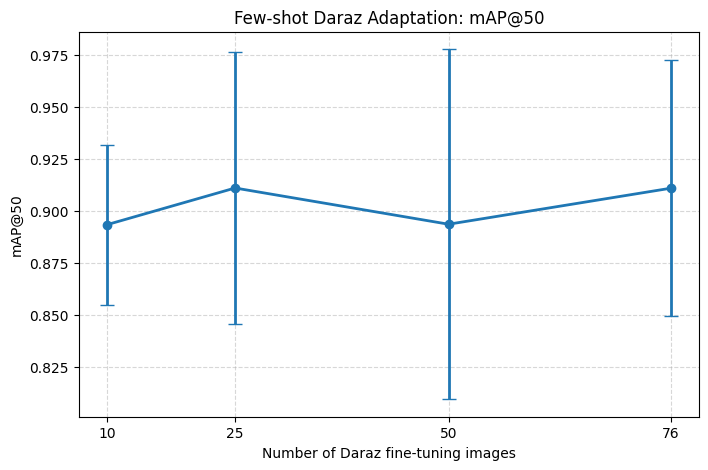

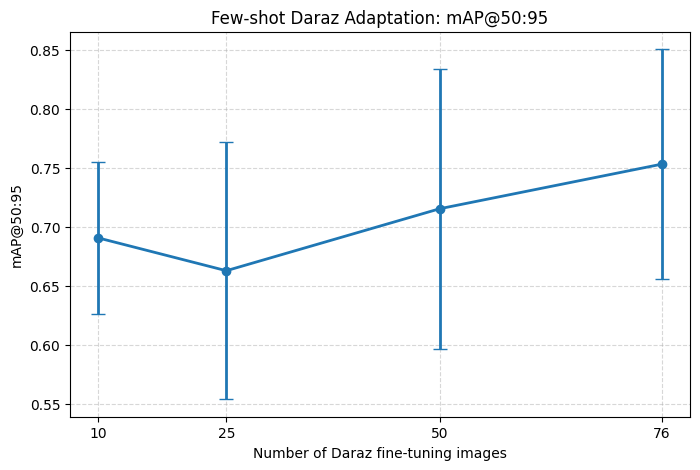

Saved clean summary: /content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_fewshot_yolov8s_clean_summary.csv
Saved mAP@50 figure: /content/drive/MyDrive/raji_sir/CrossEcomPack_results/figure5_fewshot_map50_curve.png
Saved mAP@50:95 figure: /content/drive/MyDrive/raji_sir/CrossEcomPack_results/figure5_fewshot_map50_95_curve.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")

summary_csv = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_summary.csv"
raw_csv = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_results.csv"

print("Summary exists:", summary_csv.exists())
print("Raw results exists:", raw_csv.exists())

# Load raw results
df = pd.read_csv(raw_csv)

print("Raw few-shot results:")
display(df)

# Recalculate clean summary in easier format
summary = (
    df.groupby("shot")[["precision", "recall", "map50", "map50_95"]]
    .agg(["mean", "std"])
)

# Flatten columns
summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
summary = summary.reset_index()

print("\nClean few-shot summary:")
display(summary)

# Save clean version
clean_summary_path = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_clean_summary.csv"
summary.to_csv(clean_summary_path, index=False)

# Plot mAP@50 curve
plt.figure(figsize=(8, 5))
plt.errorbar(
    summary["shot"],
    summary["map50_mean"],
    yerr=summary["map50_std"],
    marker="o",
    capsize=5,
    linewidth=2
)

plt.xlabel("Number of Daraz fine-tuning images")
plt.ylabel("mAP@50")
plt.title("Few-shot Daraz Adaptation: mAP@50")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(summary["shot"])

fig1_path = RESULTS_DIR / "figure5_fewshot_map50_curve.png"
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

# Plot mAP@50:95 curve
plt.figure(figsize=(8, 5))
plt.errorbar(
    summary["shot"],
    summary["map50_95_mean"],
    yerr=summary["map50_95_std"],
    marker="o",
    capsize=5,
    linewidth=2
)

plt.xlabel("Number of Daraz fine-tuning images")
plt.ylabel("mAP@50:95")
plt.title("Few-shot Daraz Adaptation: mAP@50:95")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(summary["shot"])

fig2_path = RESULTS_DIR / "figure5_fewshot_map50_95_curve.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved clean summary:", clean_summary_path)
print("Saved mAP@50 figure:", fig1_path)
print("Saved mAP@50:95 figure:", fig2_path)

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import torch

SOURCE_ONLY_YAML = Path("/content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml")

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Source-only YAML:", SOURCE_ONLY_YAML)
print("YAML exists:", SOURCE_ONLY_YAML.exists())
print("CUDA available:", torch.cuda.is_available())

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(SOURCE_ONLY_YAML),
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name="expF_yolov8n_source_only_10epochs",
    pretrained=True,
    optimizer="auto",
    seed=42,
    patience=10,
    cache=False,
    plots=True,
    verbose=True,
    exist_ok=True
)

print("YOLOv8n source-only training complete.")
print("Run folder:")
print(RUNS_DIR / "expF_yolov8n_source_only_10epochs")
print("Best model:")
print(RUNS_DIR / "expF_yolov8n_source_only_10epochs" / "weights" / "best.pt")

Source-only YAML: /content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml
YAML exists: True
CUDA available: True
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=3

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import torch
import gc

FOLD_ROOT = Path("/content/CrossEcomPack_local_experiments/daraz_5fold")

YOLOV8N_SOURCE_BEST = Path(
    "/content/drive/MyDrive/raji_sir/CrossEcomPack_runs/expF_yolov8n_source_only_10epochs/weights/best.pt"
)

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("YOLOv8n source-only best exists:", YOLOV8N_SOURCE_BEST.exists())
print("CUDA available:", torch.cuda.is_available())

def extract_metrics(result_obj):
    box = result_obj.box
    return {
        "precision": float(box.mp),
        "recall": float(box.mr),
        "map50": float(box.map50),
        "map50_95": float(box.map)
    }

fold_results = []

for fold in range(5):
    print("\n" + "=" * 100)
    print(f"YOLOv8n | SOURCE PRETRAIN → DARAZ FINE-TUNE | FOLD {fold}")
    print("=" * 100)

    fold_dir = FOLD_ROOT / f"fold_{fold}"
    fold_yaml = fold_dir / "data.yaml"

    train_run_name = f"modelcomp_yolov8n_fold{fold}_source_pretrain_daraz_finetune"

    model = YOLO(str(YOLOV8N_SOURCE_BEST))

    train_results = model.train(
        data=str(fold_yaml),
        epochs=30,
        imgsz=640,
        batch=8,
        device=0,
        workers=2,
        project=str(RUNS_DIR),
        name=train_run_name,
        pretrained=True,
        optimizer="AdamW",
        lr0=0.0005,
        lrf=0.01,
        seed=42,
        patience=10,
        cache=False,
        plots=True,
        verbose=False,
        exist_ok=True
    )

    best_model = RUNS_DIR / train_run_name / "weights" / "best.pt"

    del model
    gc.collect()
    torch.cuda.empty_cache()

    test_run_name = f"{train_run_name}_TEST"

    model = YOLO(str(best_model))

    test_results = model.val(
        data=str(fold_yaml),
        split="test",
        imgsz=640,
        batch=8,
        device=0,
        project=str(RUNS_DIR),
        name=test_run_name,
        save_json=True,
        plots=True
    )

    metrics = extract_metrics(test_results)

    test_img_dir = fold_dir / "test" / "images"
    test_lbl_dir = fold_dir / "test" / "labels"

    test_images = len(list(test_img_dir.glob("*.*")))
    instances = 0
    for label_file in test_lbl_dir.glob("*.txt"):
        lines = label_file.read_text(errors="ignore").strip().splitlines()
        instances += len([line for line in lines if line.strip()])

    row = {
        "model": "YOLOv8n",
        "fold": fold,
        "test_images": test_images,
        "instances": instances,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "map50": metrics["map50"],
        "map50_95": metrics["map50_95"],
        "run_name": test_run_name
    }

    fold_results.append(row)

    df_partial = pd.DataFrame(fold_results)
    partial_path = RESULTS_DIR / "modelcomp_yolov8n_5fold_partial.csv"
    df_partial.to_csv(partial_path, index=False)

    print("Fold result:", row)
    print("Partial saved:", partial_path)

    del model
    gc.collect()
    torch.cuda.empty_cache()

df = pd.DataFrame(fold_results)

summary = df[["precision", "recall", "map50", "map50_95"]].agg(["mean", "std"]).round(4)

csv_path = RESULTS_DIR / "modelcomp_yolov8n_5fold_results.csv"
xlsx_path = RESULTS_DIR / "modelcomp_yolov8n_5fold_results.xlsx"
summary_path = RESULTS_DIR / "modelcomp_yolov8n_5fold_summary.csv"

df.to_csv(csv_path, index=False)
df.to_excel(xlsx_path, index=False)
summary.to_csv(summary_path)

print("\n" + "=" * 100)
print("YOLOv8n 5-FOLD ADAPTATION COMPLETE")
print("=" * 100)

print("\nPer-fold results:")
display(df)

print("\nMean ± std summary:")
display(summary)

print("\nSaved:")
print(csv_path)
print(xlsx_path)
print(summary_path)

YOLOv8n source-only best exists: True
CUDA available: True

YOLOv8n | SOURCE PRETRAIN → DARAZ FINE-TUNE | FOLD 0
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/daraz_5fold/fold_0/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive

,model,fold,test_images,instances,precision,recall,map50,map50_95,run_name
0,YOLOv8n,0,24,26,0.953271,0.807692,0.934152,0.778158,modelcomp_yolov8n_fold0_source_pretrain_daraz_...
1,YOLOv8n,1,24,25,0.932559,0.920000,0.975364,0.796591,modelcomp_yolov8n_fold1_source_pretrain_daraz_...
2,YOLOv8n,2,24,25,0.806750,0.835102,0.870446,0.707348,modelcomp_yolov8n_fold2_source_pretrain_daraz_...
3,YOLOv8n,3,24,35,0.687825,0.755611,0.780246,0.535091,modelcomp_yolov8n_fold3_source_pretrain_daraz_...
4,YOLOv8n,4,23,25,0.946493,0.960000,0.948600,0.789951,modelcomp_yolov8n_fold4_source_pretrain_daraz_...



Mean ± std summary:


,precision,recall,map50,map50_95
mean,0.8654,0.8557,0.9018,0.7214
std,0.1160,0.0833,0.0781,0.1101



Saved:
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/modelcomp_yolov8n_5fold_results.csv
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/modelcomp_yolov8n_5fold_results.xlsx
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/modelcomp_yolov8n_5fold_summary.csv


In [ ]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import torch, gc

# Paths
SOURCE_ONLY_YAML = Path("/content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml")
FOLD0_YAML = Path("/content/CrossEcomPack_local_experiments/daraz_5fold/fold_0/data.yaml")

RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")
RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")

RUNS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Source-only YAML exists:", SOURCE_ONLY_YAML.exists())
print("Fold 0 YAML exists:", FOLD0_YAML.exists())
print("CUDA available:", torch.cuda.is_available())

# ---------------------------------------------------------
# Helper: extract metrics from Ultralytics result
# ---------------------------------------------------------
def extract_metrics(result_obj):
    box = result_obj.box
    return {
        "precision": float(box.mp),
        "recall": float(box.mr),
        "map50": float(box.map50),
        "map50_95": float(box.map)
    }

# ---------------------------------------------------------
# 1. Train YOLOv8m source-only, only if not already trained
# ---------------------------------------------------------
source_run_name = "modelcomp_yolov8m_source_only_10epochs"
source_best = RUNS_DIR / source_run_name / "weights" / "best.pt"

if source_best.exists():
    print("\nYOLOv8m source-only model already exists.")
    print("Using:", source_best)
else:
    print("\nTraining YOLOv8m source-only baseline...")

    model = YOLO("yolov8m.pt")

    source_train_results = model.train(
        data=str(SOURCE_ONLY_YAML),
        epochs=10,
        imgsz=640,
        batch=8,                 # T4-safe for YOLOv8m
        device=0,
        workers=2,
        project=str(RUNS_DIR),
        name=source_run_name,
        pretrained=True,
        optimizer="auto",
        seed=42,
        patience=10,
        cache=False,
        plots=True,
        verbose=True,
        exist_ok=True
    )

    del model
    gc.collect()
    torch.cuda.empty_cache()

print("YOLOv8m source best exists:", source_best.exists())
print("YOLOv8m source best:", source_best)

# ---------------------------------------------------------
# 2. Fine-tune YOLOv8m on Daraz Fold 0
# ---------------------------------------------------------
fold0_train_run_name = "modelcomp_yolov8m_fold0_source_pretrain_daraz_finetune"
fold0_best = RUNS_DIR / fold0_train_run_name / "weights" / "best.pt"

print("\nFine-tuning YOLOv8m on Daraz Fold 0...")

model = YOLO(str(source_best))

fold0_train_results = model.train(
    data=str(FOLD0_YAML),
    epochs=30,
    imgsz=640,
    batch=4,                  # safer for YOLOv8m fine-tuning
    device=0,
    workers=2,
    project=str(RUNS_DIR),
    name=fold0_train_run_name,
    pretrained=True,
    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    seed=42,
    patience=10,
    cache=False,
    plots=True,
    verbose=True,
    exist_ok=True
)

del model
gc.collect()
torch.cuda.empty_cache()

print("Fold 0 YOLOv8m best exists:", fold0_best.exists())
print("Fold 0 YOLOv8m best:", fold0_best)

# ---------------------------------------------------------
# 3. Evaluate YOLOv8m on Daraz Fold 0 test
# ---------------------------------------------------------
print("\nEvaluating YOLOv8m on Daraz Fold 0 test...")

test_run_name = "modelcomp_yolov8m_fold0_source_pretrain_daraz_finetune_TEST"

model = YOLO(str(fold0_best))

test_results = model.val(
    data=str(FOLD0_YAML),
    split="test",
    imgsz=640,
    batch=4,
    device=0,
    project=str(RUNS_DIR),
    name=test_run_name,
    save_json=True,
    plots=True
)

metrics = extract_metrics(test_results)

# Count test images and instances
fold0_dir = Path("/content/CrossEcomPack_local_experiments/daraz_5fold/fold_0")
test_img_dir = fold0_dir / "test" / "images"
test_lbl_dir = fold0_dir / "test" / "labels"

test_images = len(list(test_img_dir.glob("*.*")))
instances = 0

for label_file in test_lbl_dir.glob("*.txt"):
    lines = label_file.read_text(errors="ignore").strip().splitlines()
    instances += len([line for line in lines if line.strip()])

# Model file size
model_size_mb = round(fold0_best.stat().st_size / (1024 * 1024), 2)

row = {
    "model": "YOLOv8m",
    "comparison_setting": "Fold 0 only",
    "training_strategy": "source-pretrain -> Daraz fine-tune",
    "test_images": test_images,
    "instances": instances,
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "map50": metrics["map50"],
    "map50_95": metrics["map50_95"],
    "model_size_mb": model_size_mb,
    "source_run": source_run_name,
    "fold0_test_run": test_run_name
}

df = pd.DataFrame([row])

csv_path = RESULTS_DIR / "modelcomp_yolov8m_fold0_result.csv"
xlsx_path = RESULTS_DIR / "modelcomp_yolov8m_fold0_result.xlsx"

df.to_csv(csv_path, index=False)
df.to_excel(xlsx_path, index=False)

print("\nYOLOv8m Fold 0 model-comparison result:")
display(df)

print("\nSaved:")
print(csv_path)
print(xlsx_path)

del model
gc.collect()
torch.cuda.empty_cache()

Source-only YAML exists: True
Fold 0 YAML exists: True
CUDA available: True

Training YOLOv8m source-only baseline...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CrossEcomPack_local_experiments/source_only_public_train_daraz_test/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

In [ ]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")
RUNS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_runs")

print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("RUNS_DIR exists:", RUNS_DIR.exists())

files_to_check = {
    "YOLOv8s 5-fold summary": RESULTS_DIR / "daraz_5fold_yolov8s_source_pretrain_finetune_summary.csv",
    "YOLOv8s 5-fold full results": RESULTS_DIR / "daraz_5fold_yolov8s_source_pretrain_finetune_results.csv",
    "Few-shot clean summary": RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_clean_summary.csv",
    "Few-shot full results": RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_results.csv",
    "YOLOv8n 5-fold summary": RESULTS_DIR / "modelcomp_yolov8n_5fold_summary.csv",
    "YOLOv8n 5-fold full results": RESULTS_DIR / "modelcomp_yolov8n_5fold_results.csv",
}

print("\nSaved result files:")
for name, path in files_to_check.items():
    print(f"{name}: {path.exists()} | {path}")

# Load available summaries
loaded = {}

for name, path in files_to_check.items():
    if path.exists():
        try:
            loaded[name] = pd.read_csv(path)
            print(f"\n{name}")
            display(loaded[name])
        except Exception as e:
            print(f"Could not read {name}: {e}")

# Build paper-ready summary
paper_rows = []

# YOLOv8s main result
y8s_summary_path = files_to_check["YOLOv8s 5-fold summary"]
if y8s_summary_path.exists():
    y8s = pd.read_csv(y8s_summary_path, index_col=0)
    paper_rows.append({
        "experiment": "Main 5-fold adaptation",
        "model": "YOLOv8s",
        "setting": "Public source pretrain → Daraz fine-tune",
        "precision_mean": y8s.loc["mean", "precision"],
        "precision_std": y8s.loc["std", "precision"],
        "recall_mean": y8s.loc["mean", "recall"],
        "recall_std": y8s.loc["std", "recall"],
        "map50_mean": y8s.loc["mean", "map50"],
        "map50_std": y8s.loc["std", "map50"],
        "map50_95_mean": y8s.loc["mean", "map50_95"],
        "map50_95_std": y8s.loc["std", "map50_95"],
        "notes": "Primary conference result; 5-fold Daraz target evaluation"
    })

# YOLOv8n comparison result
y8n_summary_path = files_to_check["YOLOv8n 5-fold summary"]
if y8n_summary_path.exists():
    y8n = pd.read_csv(y8n_summary_path, index_col=0)
    paper_rows.append({
        "experiment": "Lightweight model comparison",
        "model": "YOLOv8n",
        "setting": "Public source pretrain → Daraz fine-tune",
        "precision_mean": y8n.loc["mean", "precision"],
        "precision_std": y8n.loc["std", "precision"],
        "recall_mean": y8n.loc["mean", "recall"],
        "recall_std": y8n.loc["std", "recall"],
        "map50_mean": y8n.loc["mean", "map50"],
        "map50_std": y8n.loc["std", "map50"],
        "map50_95_mean": y8n.loc["mean", "map50_95"],
        "map50_95_std": y8n.loc["std", "map50_95"],
        "notes": "Lightweight deployment baseline; smaller but slightly lower localization quality"
    })

paper_summary = pd.DataFrame(paper_rows)

paper_summary_csv = RESULTS_DIR / "PAPER_READY_main_results_summary.csv"
paper_summary_xlsx = RESULTS_DIR / "PAPER_READY_main_results_summary.xlsx"

paper_summary.to_csv(paper_summary_csv, index=False)
paper_summary.to_excel(paper_summary_xlsx, index=False)

print("\nPAPER-READY MAIN RESULTS SUMMARY")
display(paper_summary)

print("\nSaved:")
print(paper_summary_csv)
print(paper_summary_xlsx)

# Create markdown progress report
report_path = RESULTS_DIR / "PAPER_READY_experiment_status_report.md"

report = f"""# CrossEcomPack Experiment Status Report

## Status

Heavy GPU training is stopped due runtime/GPU constraints. The completed experiments are sufficient for the main conference-paper arc.

## Completed Core Results

### Main 5-fold Daraz adaptation

Model: YOLOv8s
Setting: Public source pretraining followed by Daraz target-domain fine-tuning
Result: mAP@50 = 0.9109 ± 0.0615, mAP@50:95 = 0.7530 ± 0.0973

### Few-shot Daraz adaptation

Completed for 10, 25, 50, and 76 Daraz fine-tuning images across 5 folds.
Main insight: mAP@50 is already strong with 10–25 images, while mAP@50:95 improves most with 76 images.

### Lightweight model comparison

Model: YOLOv8n
Result: mAP@50 = 0.9018, mAP@50:95 = 0.7214
Interpretation: YOLOv8n is much smaller and competitive, but YOLOv8s gives stronger tighter localization.

## Experiments to Stop

Do not continue YOLOv8m, YOLO11, or RT-DETR unless extra GPU is available. These can be listed as future extended benchmarking.

## Paper Direction

The paper should focus on:
1. CrossEcomPack dataset construction
2. Source-to-target adaptation from mixed public e-commerce data to Daraz
3. 5-fold Daraz adaptation result
4. Few-shot Daraz adaptation curve
5. YOLOv8n vs YOLOv8s lightweight comparison
6. Limitations: Daraz shipping_label annotations are not yet available

## Claims Allowed

- Harmonized cross-ecommerce package-label benchmark
- Low-resource Daraz package-domain adaptation
- Few-shot target-domain adaptation study
- Lightweight detector comparison

## Claims Not Allowed

- Daraz-only 13K dataset
- OCR or barcode recognition
- Inventory automation
- Real warehouse deployment
- Daraz shipping-label localization unless Daraz label boxes are added later
"""

report_path.write_text(report)

print("\nSaved report:")
print(report_path)

RESULTS_DIR exists: True
RUNS_DIR exists: True

Saved result files:
YOLOv8s 5-fold summary: True | /content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_yolov8s_source_pretrain_finetune_summary.csv
YOLOv8s 5-fold full results: True | /content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_yolov8s_source_pretrain_finetune_results.csv
Few-shot clean summary: True | /content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_fewshot_yolov8s_clean_summary.csv
Few-shot full results: True | /content/drive/MyDrive/raji_sir/CrossEcomPack_results/daraz_5fold_fewshot_yolov8s_results.csv
YOLOv8n 5-fold summary: True | /content/drive/MyDrive/raji_sir/CrossEcomPack_results/modelcomp_yolov8n_5fold_summary.csv
YOLOv8n 5-fold full results: True | /content/drive/MyDrive/raji_sir/CrossEcomPack_results/modelcomp_yolov8n_5fold_results.csv

YOLOv8s 5-fold summary


,Unnamed: 0,precision,recall,map50,map50_95
0,mean,0.8603,0.8885,0.9109,0.7530
1,std,0.1264,0.0835,0.0615,0.0973



YOLOv8s 5-fold full results


,fold,test_images,instances,precision,recall,map50,map50_95,run_name
0,0,24,26,1.000000,0.833000,0.942000,0.799000,fold0_yolov8s_source_pretrain_daraz_finetune_TEST
1,1,24,25,0.884364,0.917823,0.942579,0.800705,fold1_yolov8s_source_pretrain_daraz_finetune_TEST
2,2,24,25,0.763548,0.960000,0.920591,0.786223,fold2_yolov8s_source_pretrain_daraz_finetune_TEST
3,3,24,35,0.699836,0.771429,0.802511,0.579322,fold3_yolov8s_source_pretrain_daraz_finetune_TEST
4,4,23,25,0.953655,0.960000,0.947000,0.799771,fold4_yolov8s_source_pretrain_daraz_finetune_TEST



Few-shot clean summary


...


YOLOv8n 5-fold full results


,model,fold,test_images,instances,precision,recall,map50,map50_95,run_name
0,YOLOv8n,0,24,26,0.953271,0.807692,0.934152,0.778158,modelcomp_yolov8n_fold0_source_pretrain_daraz_...
1,YOLOv8n,1,24,25,0.932559,0.920000,0.975364,0.796591,modelcomp_yolov8n_fold1_source_pretrain_daraz_...
2,YOLOv8n,2,24,25,0.806750,0.835102,0.870446,0.707348,modelcomp_yolov8n_fold2_source_pretrain_daraz_...
3,YOLOv8n,3,24,35,0.687825,0.755611,0.780246,0.535091,modelcomp_yolov8n_fold3_source_pretrain_daraz_...
4,YOLOv8n,4,23,25,0.946493,0.960000,0.948600,0.789951,modelcomp_yolov8n_fold4_source_pretrain_daraz_...



PAPER-READY MAIN RESULTS SUMMARY


,experiment,model,setting,precision_mean,precision_std,recall_mean,recall_std,map50_mean,map50_std,map50_95_mean,map50_95_std,notes
0,Main 5-fold adaptation,YOLOv8s,Public source pretrain → Daraz fine-tune,0.8603,0.1264,0.8885,0.0835,0.9109,0.0615,0.7530,0.0973,Primary conference result; 5-fold Daraz target...
1,Lightweight model comparison,YOLOv8n,Public source pretrain → Daraz fine-tune,0.8654,0.1160,0.8557,0.0833,0.9018,0.0781,0.7214,0.1101,Lightweight deployment baseline; smaller but s...



Saved:
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/PAPER_READY_main_results_summary.csv
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/PAPER_READY_main_results_summary.xlsx

Saved report:
/content/drive/MyDrive/raji_sir/CrossEcomPack_results/PAPER_READY_experiment_status_report.md


Figures will be saved to: /content/drive/MyDrive/raji_sir/CrossEcomPack_results/paper_figures


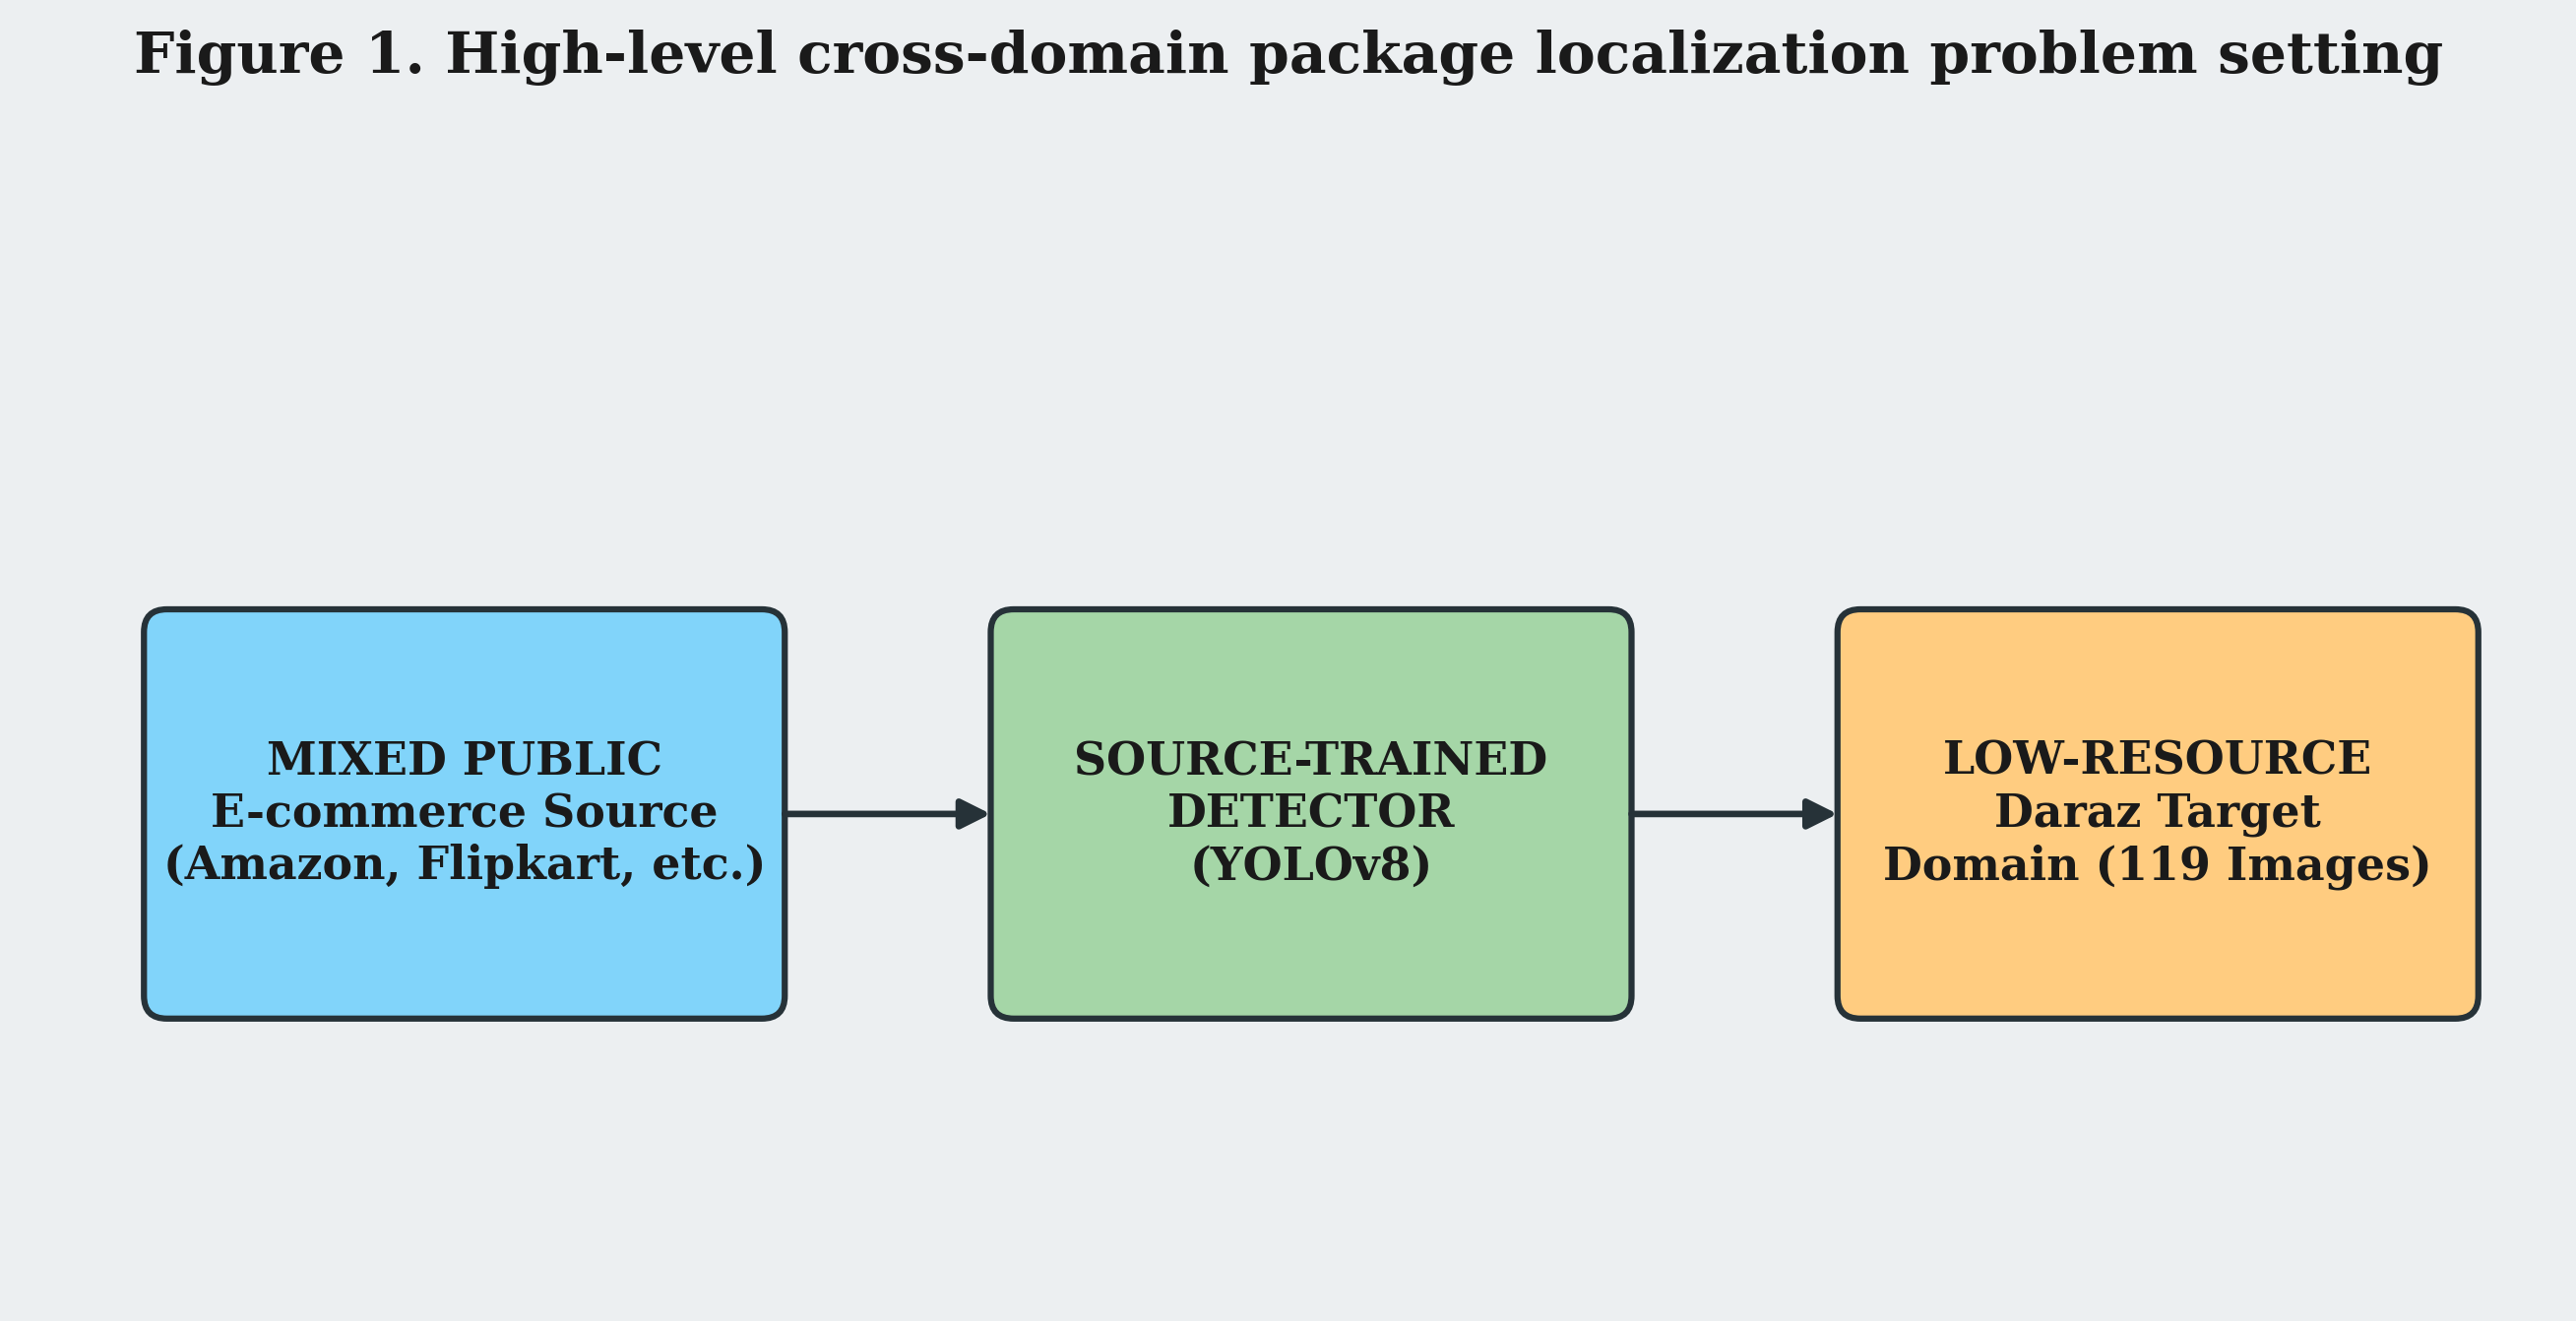

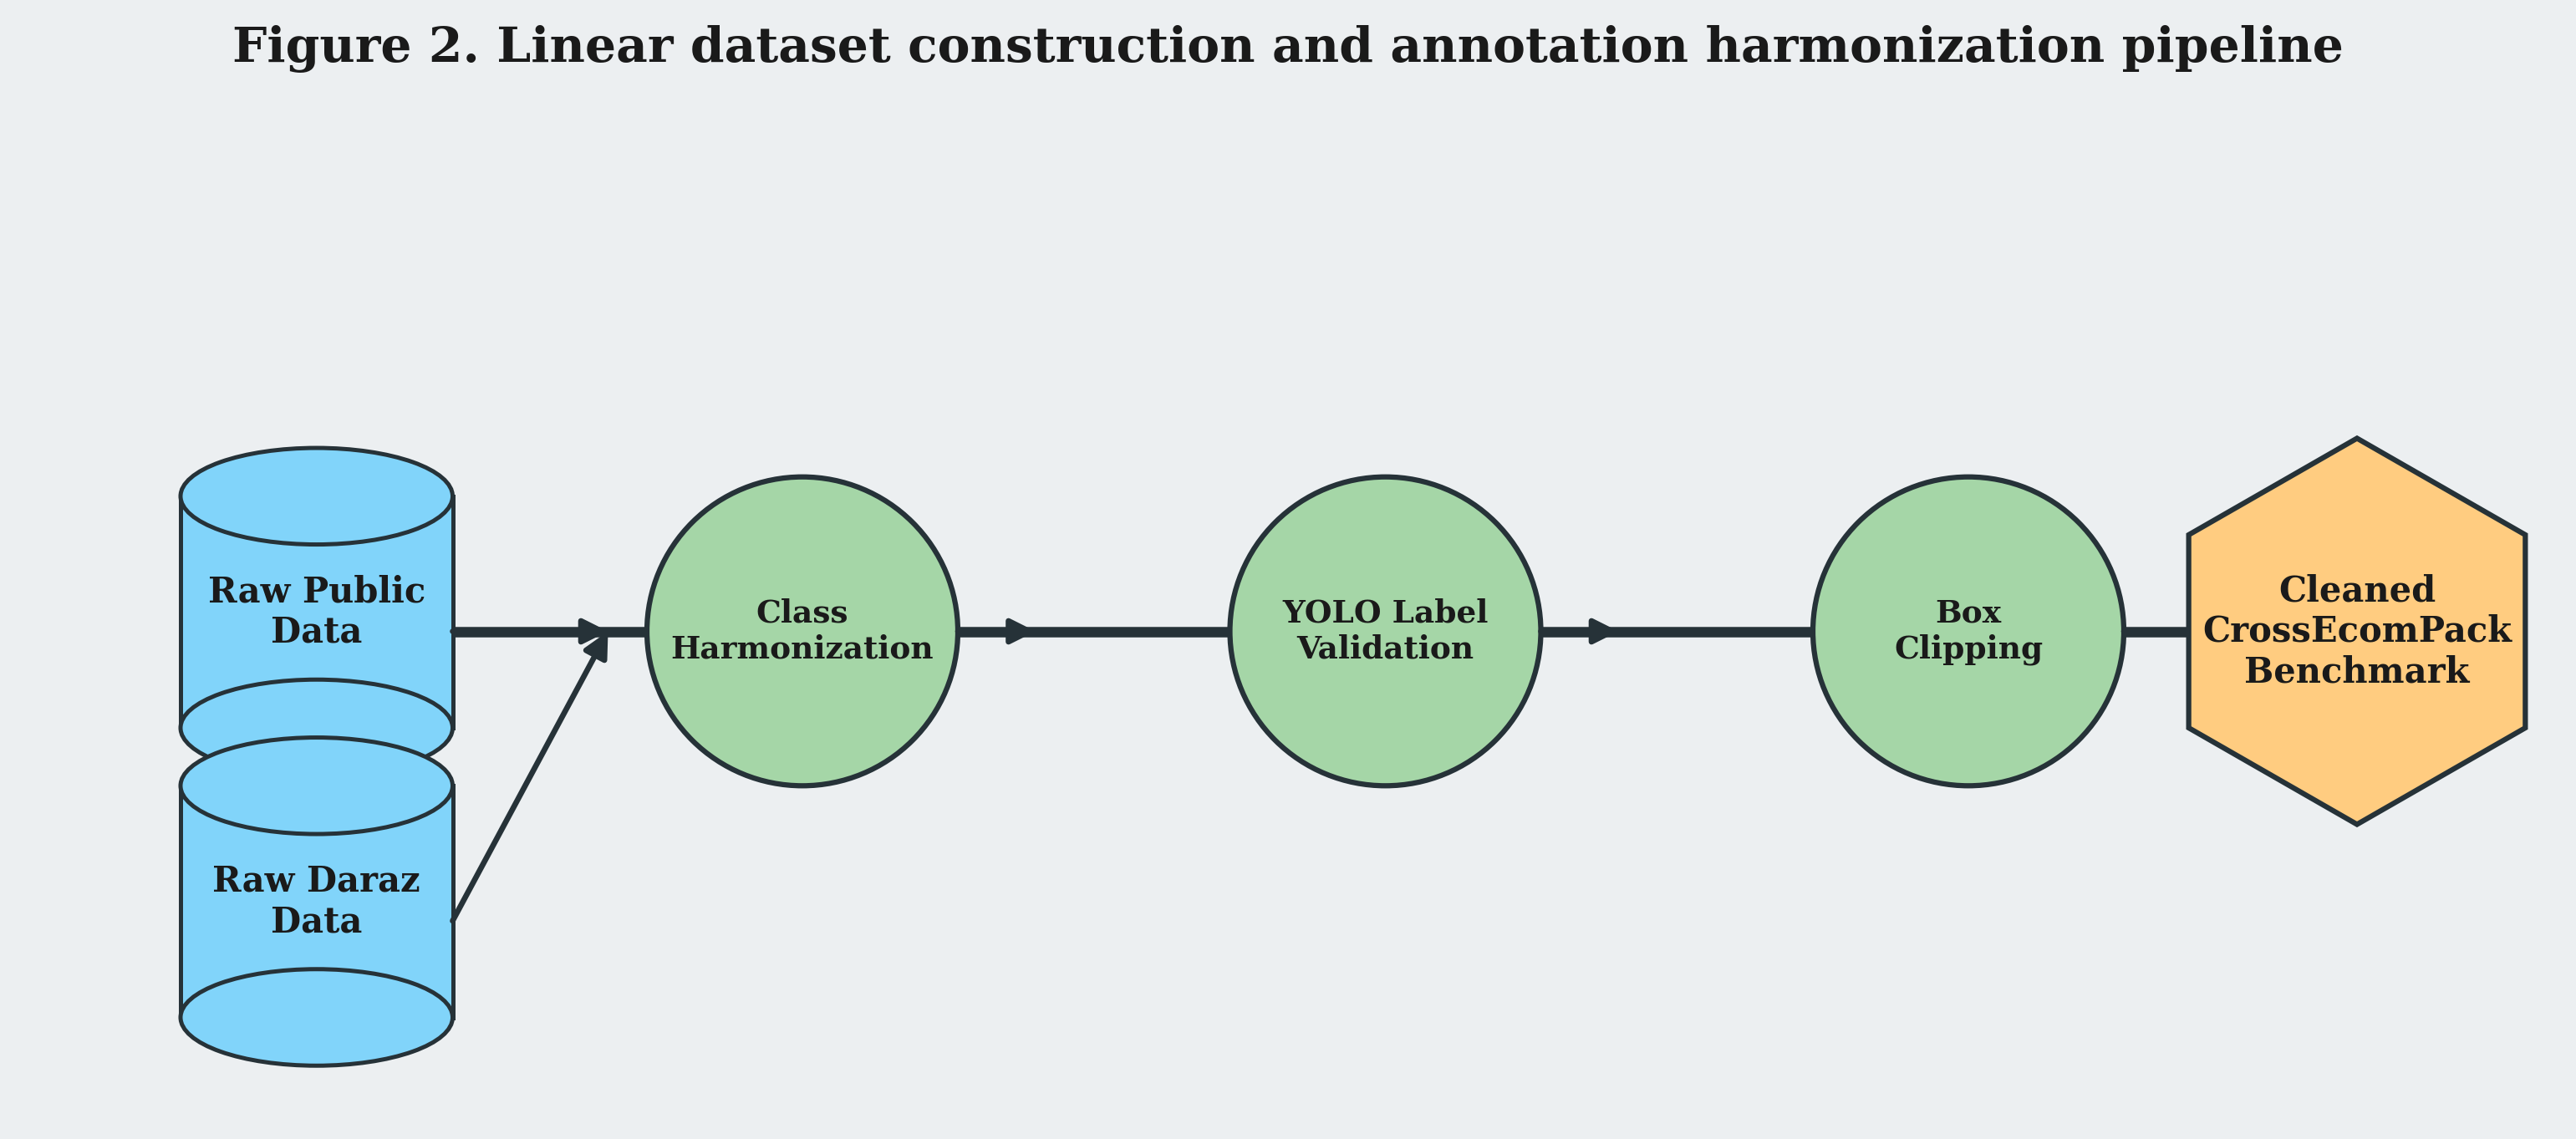

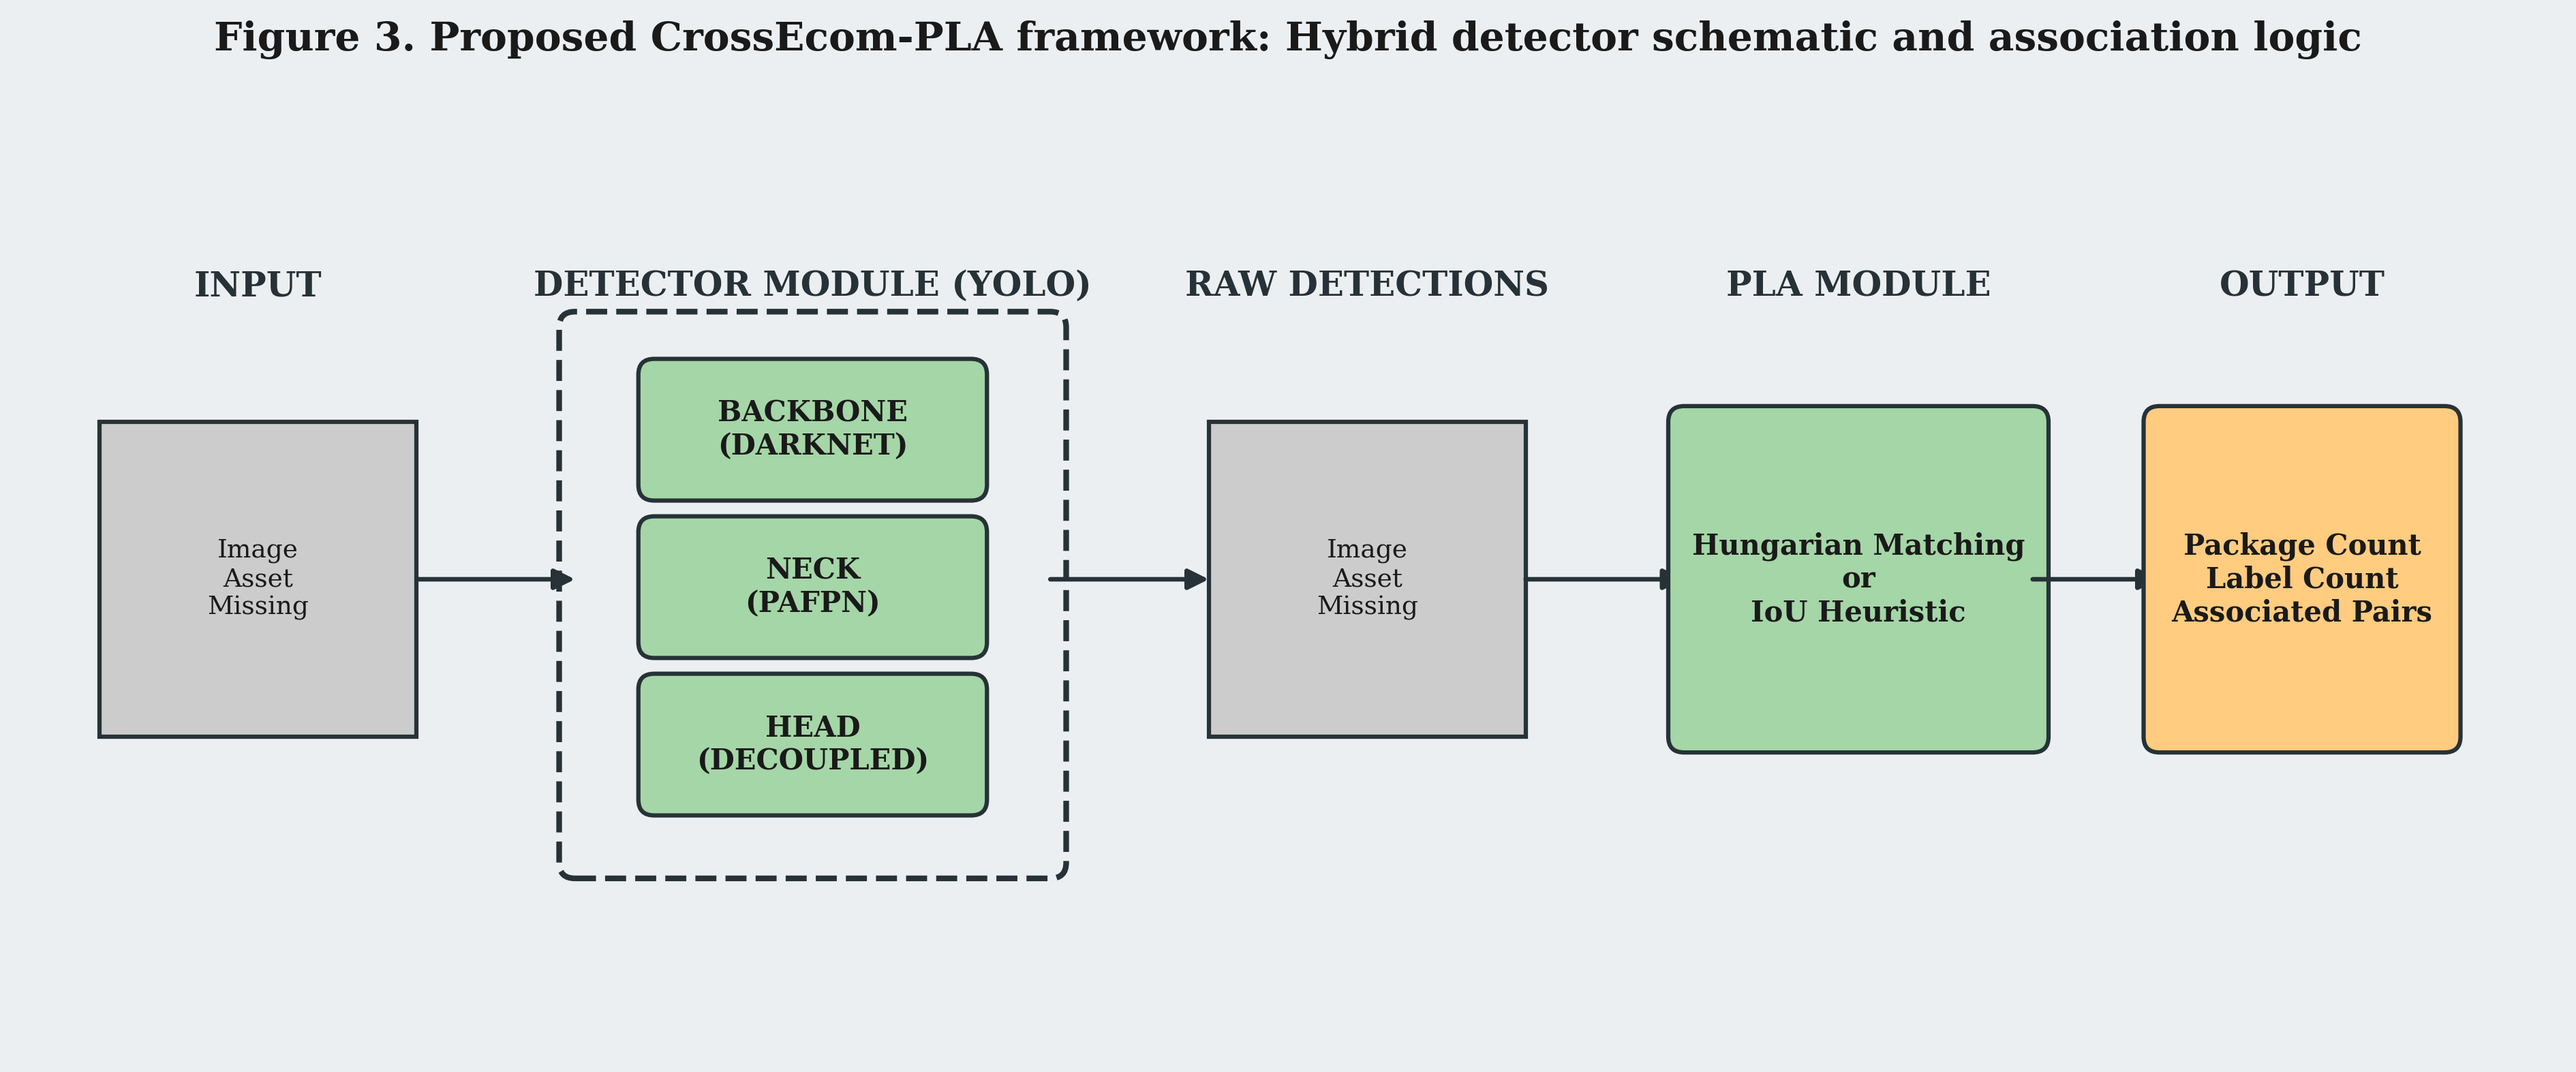

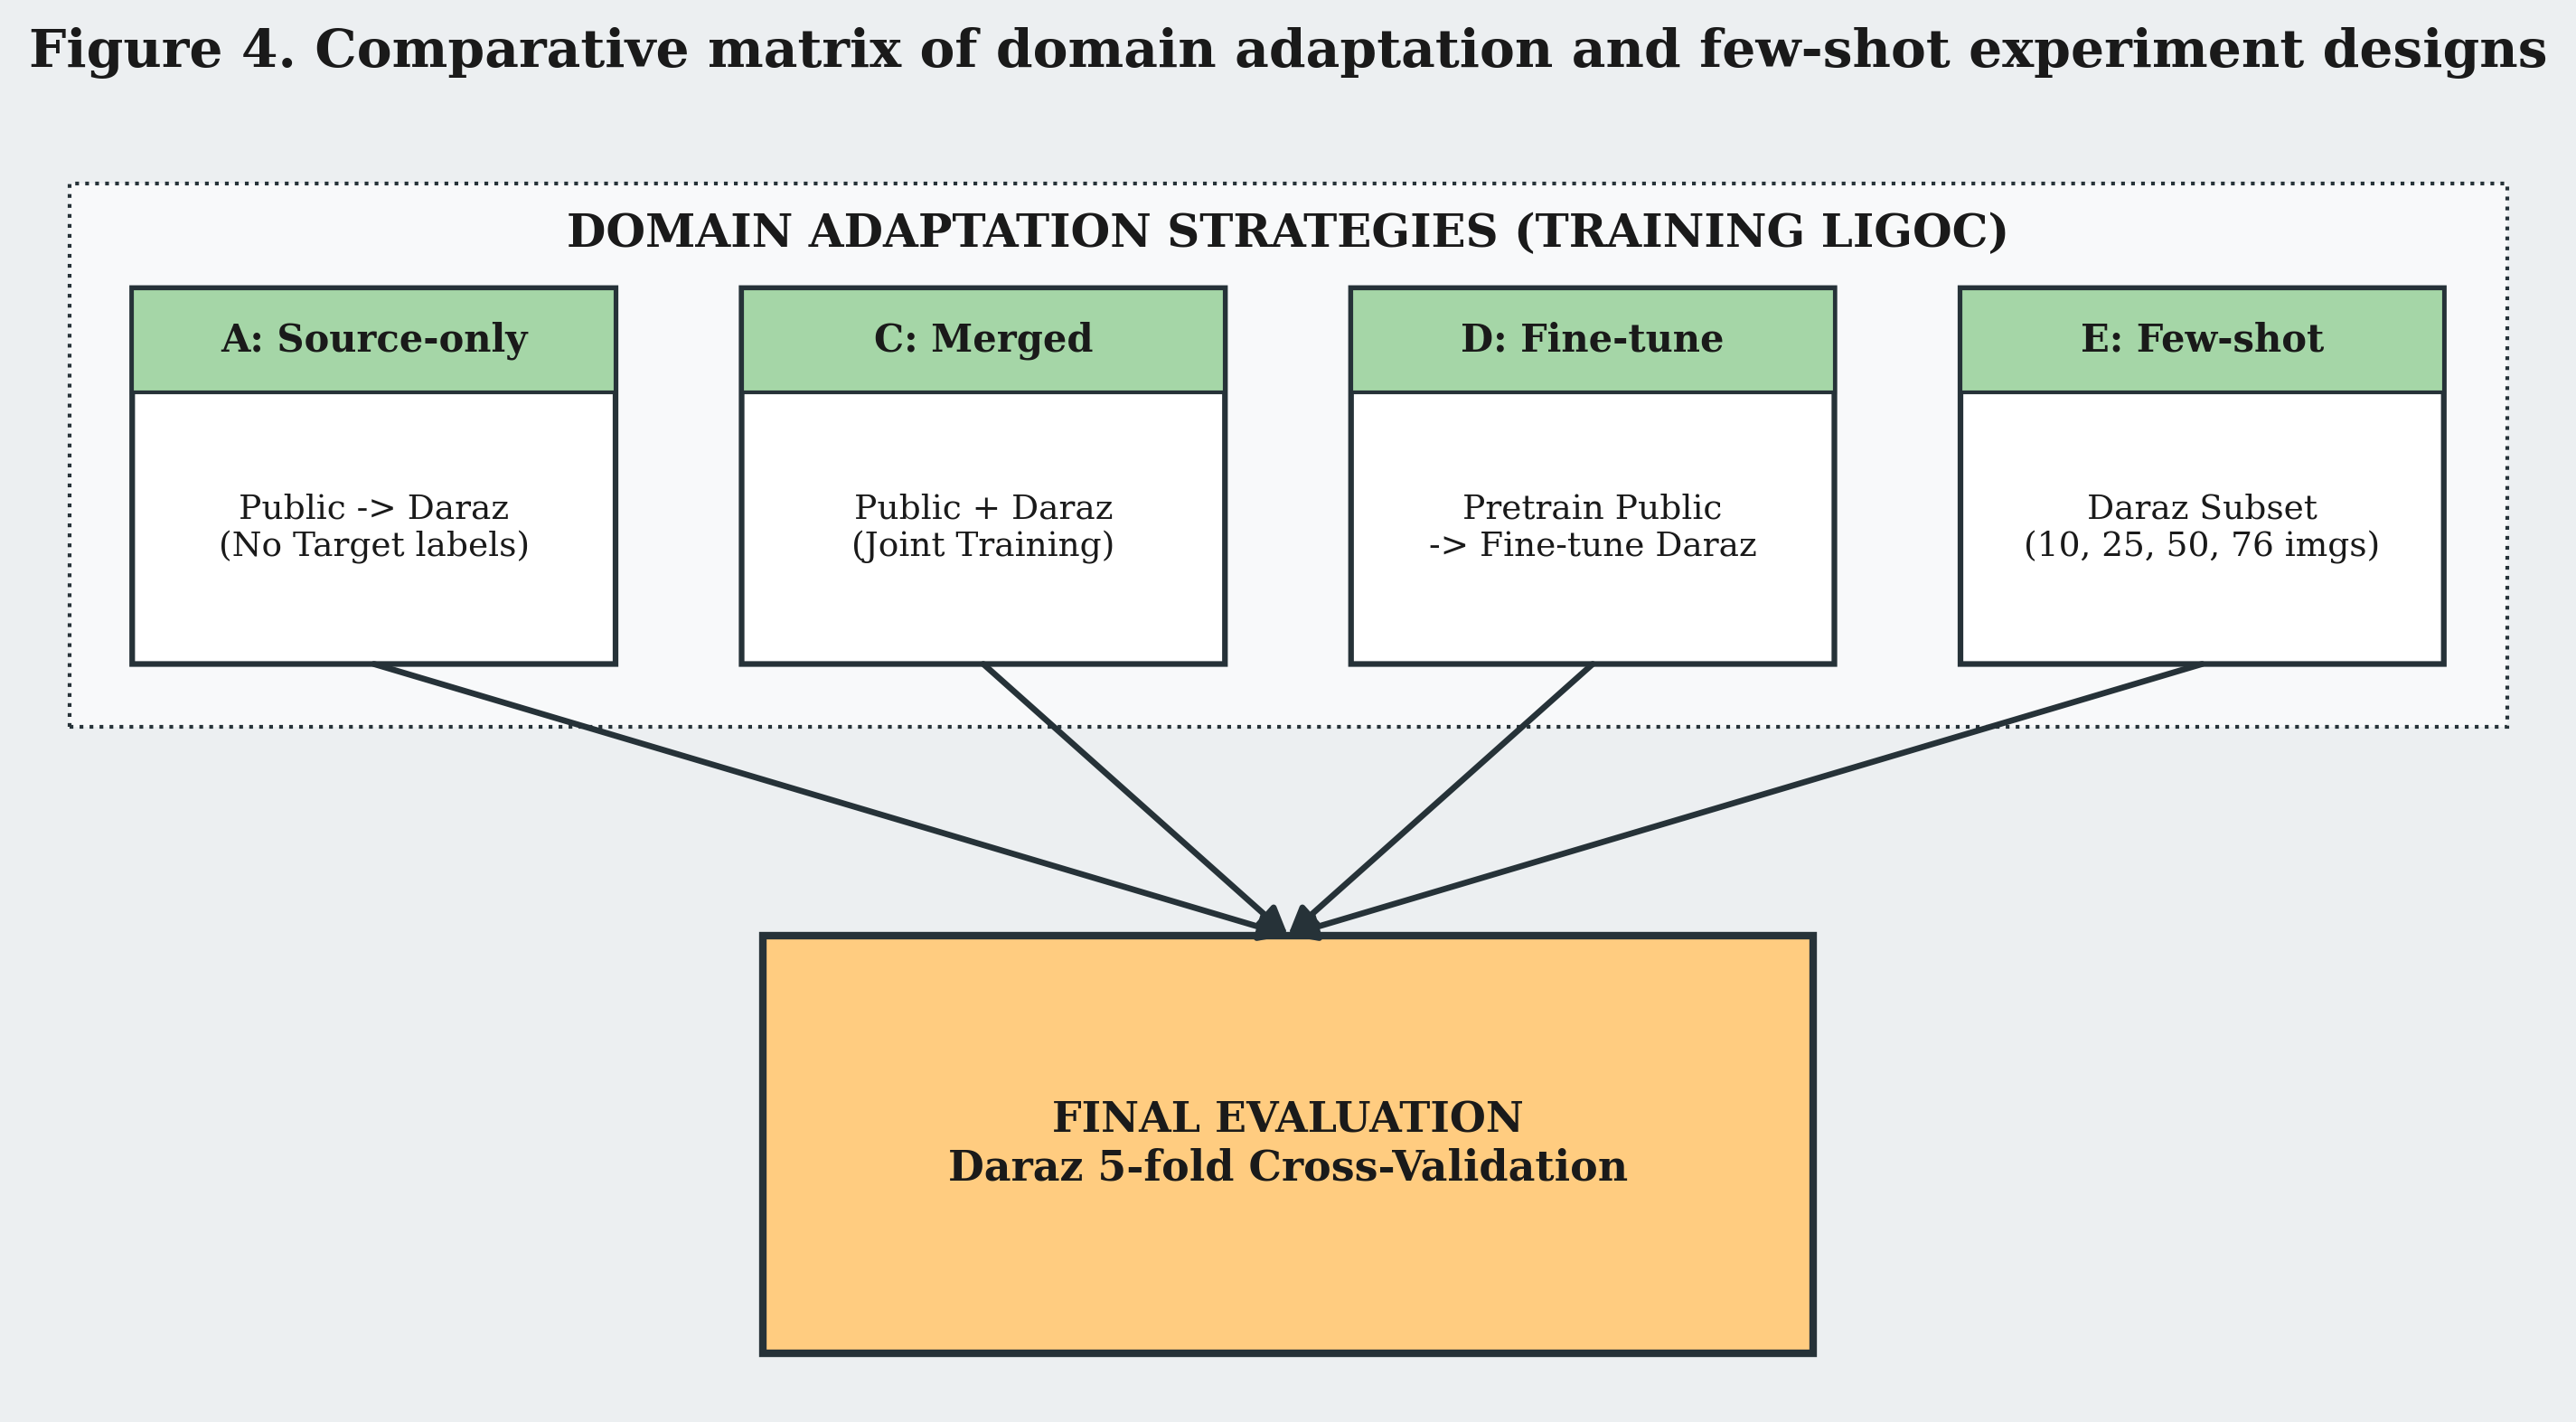

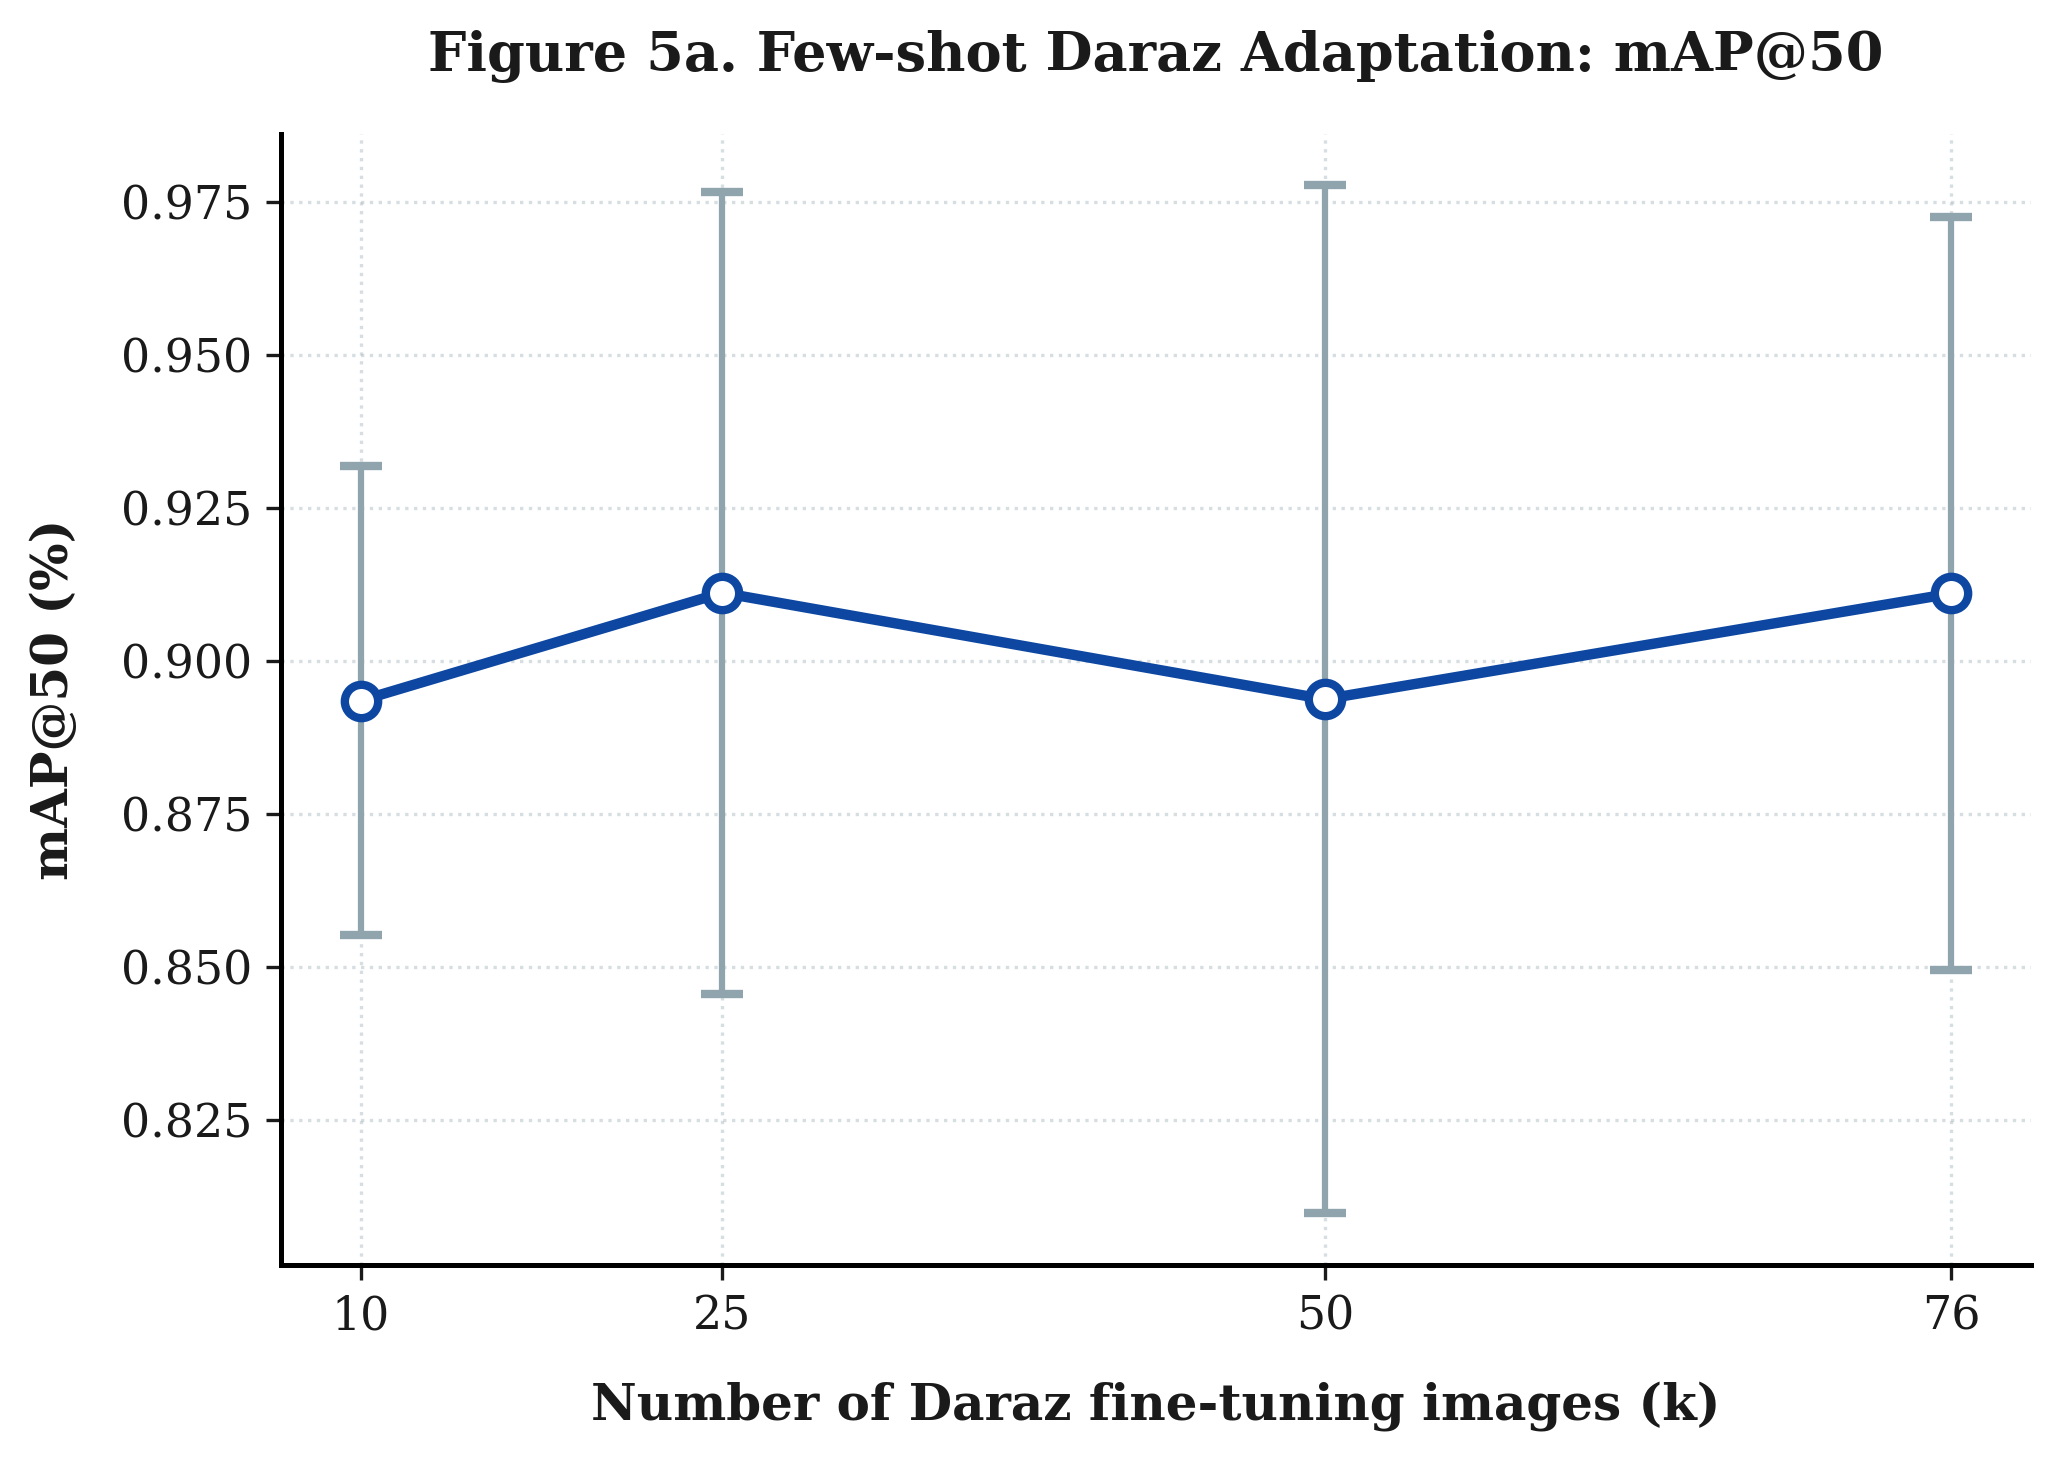

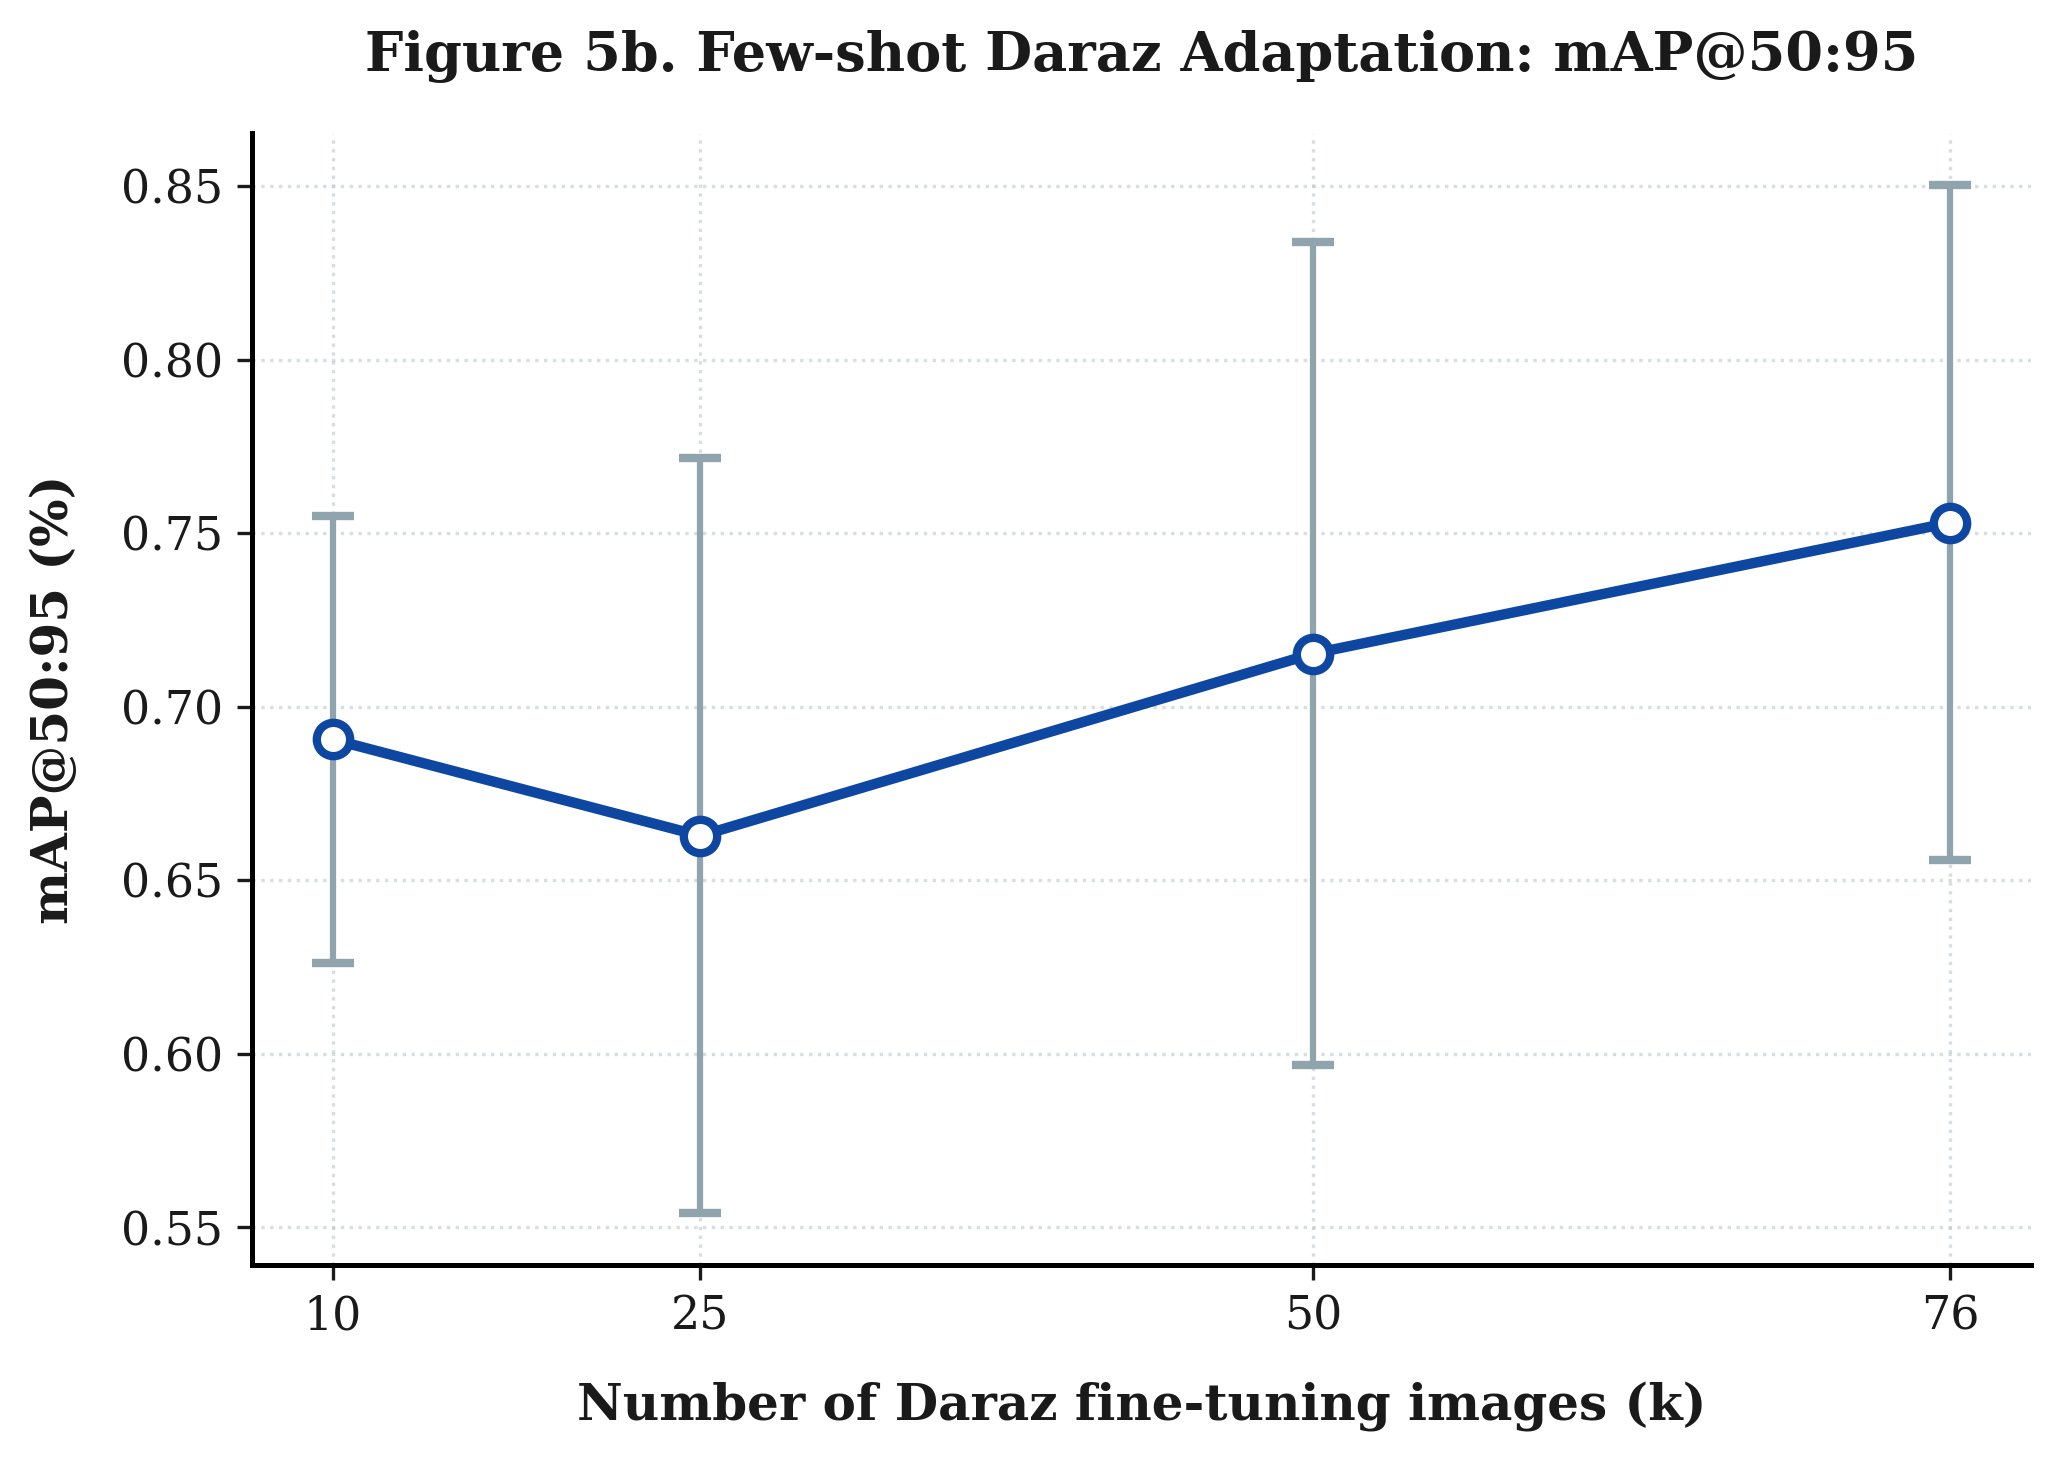


Saved and displayed all unique Q1-formatted figures successfully.


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# =========================================================
# GLOBAL ACADEMIC STYLING
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.2,
    "text.color": "#1A1A1A",
})

# Refined Semantic Palette
CLR_SOURCE = "#81D4FA"  # Strong Blue (Raw Data)
CLR_PROCESS = "#A5D6A7" # Strong Green (Model/logic)
CLR_TARGET = "#FFCC80"  # Strong Orange (Output/Evaluation)
CLR_EDGE = "#263238"    # Near Black
CLR_BG = "#ECEFF1"     # Very Light Gray Background for figures

RESULTS_DIR = Path("/content/drive/MyDrive/raji_sir/CrossEcomPack_results")
FIG_DIR = RESULTS_DIR / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:", FIG_DIR)

# --- Common helper functions ---
def draw_standard_arrow(ax, start, end):
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="-|>", mutation_scale=15,
                                linewidth=1.6, color=CLR_EDGE, shrinkA=0, shrinkB=0))

def clean_plot(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=":", alpha=0.5, color="#B0BEC5")

# ==============================================================================
# Figure 1 — Problem setting
# ==============================================================================
def plot_figure_1():
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(CLR_BG)
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 5)
    ax.axis("off")

    # Source
    draw_box_3d = patches.FancyBboxPatch((0.5, 1.2), 2.8, 1.8, boxstyle="round,pad=0,rounding_size=0.1",
                                       linewidth=1.5, edgecolor=CLR_EDGE, facecolor=CLR_SOURCE)
    ax.add_patch(draw_box_3d)
    ax.text(1.9, 2.1, "MIXED PUBLIC\nE-commerce Source\n(Amazon, Flipkart, etc.)",
            ha="center", va="center", fontsize=11, fontweight="bold", wrap=True)

    # Detector
    draw_box_3d_proc = patches.FancyBboxPatch((4.2, 1.2), 2.8, 1.8, boxstyle="round,pad=0,rounding_size=0.1",
                                           linewidth=1.5, edgecolor=CLR_EDGE, facecolor=CLR_PROCESS)
    ax.add_patch(draw_box_3d_proc)
    ax.text(5.6, 2.1, "SOURCE-TRAINED\nDETECTOR\n(YOLOv8)",
            ha="center", va="center", fontsize=11, fontweight="bold", wrap=True)

    # Target
    draw_box_3d_tgt = patches.FancyBboxPatch((7.9, 1.2), 2.8, 1.8, boxstyle="round,pad=0,rounding_size=0.1",
                                          linewidth=1.5, edgecolor=CLR_EDGE, facecolor=CLR_TARGET)
    ax.add_patch(draw_box_3d_tgt)
    ax.text(9.3, 2.1, "LOW-RESOURCE\nDaraz Target\nDomain (119 Images)",
            ha="center", va="center", fontsize=11, fontweight="bold", wrap=True)

    # Arrows
    draw_standard_arrow(ax, (3.3, 2.1), (4.2, 2.1))
    draw_standard_arrow(ax, (7.0, 2.1), (7.9, 2.1))

    ax.set_title("Figure 1. High-level cross-domain package localization problem setting",
                 fontweight="bold", fontsize=14, pad=20)

    plt.savefig(FIG_DIR / "Figure1_3D_problem_setting.png", bbox_inches="tight")
    plt.show()
    plt.close(fig) # Clears the figure to prevent merging with the next one

# ==============================================================================
# Figure 2 — Dataset construction pipeline
# ==============================================================================
def draw_db_icon(ax, x, y, r, h, text, color=CLR_SOURCE):
    ellipse = patches.Ellipse((x, y), 2*r, 0.5, edgecolor=CLR_EDGE, facecolor=color, linewidth=1.2, zorder=3)
    ax.add_patch(ellipse)
    rect = patches.Rectangle((x-r, y), 2*r, h, edgecolor=CLR_EDGE, facecolor=color, linewidth=1.2, zorder=2)
    ax.add_patch(rect)
    ellipse_top = patches.Ellipse((x, y+h), 2*r, 0.5, edgecolor=CLR_EDGE, facecolor=color, linewidth=1.2, zorder=4)
    ax.add_patch(ellipse_top)
    ax.text(x, y+h/2, text, ha="center", va="center", fontsize=10, fontweight="bold", wrap=True, zorder=5)

def plot_figure_2():
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor(CLR_BG)
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 5)
    ax.axis("off")

    ax.plot([1, 12], [2.5, 2.5], color=CLR_EDGE, linewidth=3, zorder=1)

    draw_db_icon(ax, 1.5, 2.0, 0.7, 1.2, "Raw Public\nData", CLR_SOURCE)
    draw_db_icon(ax, 1.5, 0.5, 0.7, 1.2, "Raw Daraz\nData", CLR_SOURCE)
    draw_standard_arrow(ax, (2.2, 2.5), (3.0, 2.5))
    draw_standard_arrow(ax, (2.2, 1.0), (3.0, 2.5))

    proc_steps = [
        (4.0, "Class\nHarmonization"),
        (7.0, "YOLO Label\nValidation"),
        (10.0, "Box\nClipping"),
    ]
    for x, text in proc_steps:
        circle = patches.Circle((x, 2.5), 0.8, edgecolor=CLR_EDGE, facecolor=CLR_PROCESS, linewidth=1.5, zorder=3)
        ax.add_patch(circle)
        ax.text(x, 2.5, text, ha="center", va="center", fontsize=9, fontweight="bold", wrap=True, zorder=4)
        if x < 10: draw_standard_arrow(ax, (x+0.8, 2.5), (x+1.2, 2.5))

    draw_standard_arrow(ax, (10.8, 2.5), (11.5, 2.5))

    polygon = patches.RegularPolygon((12.0, 2.5), 6, radius=1.0, edgecolor=CLR_EDGE, facecolor=CLR_TARGET, linewidth=1.5, zorder=3)
    ax.add_patch(polygon)
    ax.text(12.0, 2.5, "Cleaned\nCrossEcomPack\nBenchmark", ha="center", va="center", fontsize=10, fontweight="bold", wrap=True, zorder=4)

    ax.set_title("Figure 2. Linear dataset construction and annotation harmonization pipeline",
                 fontweight="bold", fontsize=14, pad=25)

    plt.savefig(FIG_DIR / "Figure2_timeline_pipeline.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ==============================================================================
# Figure 3 — Proposed CrossEcom-PLA framework (Aligned)
# ==============================================================================
def plot_figure_3():
    fig, ax = plt.subplots(figsize=(16, 6))
    fig.patch.set_facecolor(CLR_BG)
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 6)
    ax.axis("off")

    asset_dir = FIG_DIR / "assets"
    asset_dir.mkdir(parents=True, exist_ok=True)

    def draw_node(x, y, w, h, text, facecolor, edgecolor=CLR_EDGE):
        rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                      edgecolor=edgecolor, facecolor=facecolor, linewidth=1.5, zorder=3)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10, fontweight="bold", zorder=4)

    def embed_image_or_placeholder(path, xy, w, h, text="Image\nAsset\nMissing"):
        if Path(path).exists():
            img = mpimg.imread(path)
            imagebox = OffsetImage(img, zoom=0.25)
            ab = AnnotationBbox(imagebox, (xy[0]+w/2, xy[1]+h/2), frameon=False)
            ax.add_artist(ab)
        else:
            rect = patches.Rectangle((xy[0], xy[1]), w, h, facecolor="#CCCCCC", edgecolor=CLR_EDGE, linewidth=1.5)
            ax.add_patch(rect)
            ax.text(xy[0]+w/2, xy[1]+h/2, text, ha="center", va="center", fontsize=9)

    # 1. INPUT
    ax.text(1.5, 4.8, "INPUT", fontweight="bold", fontsize=12, color=CLR_EDGE, ha="center")
    embed_image_or_placeholder(asset_dir / "input_package_example.png", (0.5, 2.0), 2.0, 2.0)
    draw_standard_arrow(ax, (2.5, 3.0), (3.5, 3.0))

    # 2. DETECTOR MODULE
    ax.text(5.0, 4.8, "DETECTOR MODULE (YOLO)", fontweight="bold", fontsize=12, color=CLR_EDGE, ha="center")
    det_rect = patches.FancyBboxPatch((3.5, 1.2), 3.0, 3.4, boxstyle="round,pad=0.1",
                                     edgecolor=CLR_EDGE, facecolor="none", linewidth=2, linestyle="--")
    ax.add_patch(det_rect)
    draw_node(4.0, 3.6, 2.0, 0.7, "BACKBONE\n(DARKNET)", CLR_PROCESS)
    draw_node(4.0, 2.6, 2.0, 0.7, "NECK\n(PAFPN)", CLR_PROCESS)
    draw_node(4.0, 1.6, 2.0, 0.7, "HEAD\n(DECOUPLED)", CLR_PROCESS)
    draw_standard_arrow(ax, (6.5, 3.0), (7.5, 3.0))

    # 3. RAW DETECTIONS
    ax.text(8.5, 4.8, "RAW DETECTIONS", fontweight="bold", fontsize=12, color=CLR_EDGE, ha="center")
    embed_image_or_placeholder(asset_dir / "detection_visualization.png", (7.5, 2.0), 2.0, 2.0)
    draw_standard_arrow(ax, (9.5, 3.0), (10.5, 3.0))

    # 4. PLA MODULE
    ax.text(11.6, 4.8, "PLA MODULE", fontweight="bold", fontsize=12, color=CLR_EDGE, ha="center")
    draw_node(10.5, 2.0, 2.2, 2.0, "Hungarian Matching\nor\nIoU Heuristic", CLR_PROCESS)
    draw_standard_arrow(ax, (12.7, 3.0), (13.5, 3.0))

    # 5. OUTPUT
    ax.text(14.4, 4.8, "OUTPUT", fontweight="bold", fontsize=12, color=CLR_EDGE, ha="center")
    draw_node(13.5, 2.0, 1.8, 2.0, "Package Count\nLabel Count\nAssociated Pairs", CLR_TARGET)

    ax.set_title("Figure 3. Proposed CrossEcom-PLA framework: Hybrid detector schematic and association logic",
                 fontweight="bold", fontsize=14, pad=20)

    plt.savefig(FIG_DIR / "Figure3_realistic_framework.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ==============================================================================
# Figure 4 — Domain adaptation experiment design
# ==============================================================================
def plot_figure_4():
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(CLR_BG)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6)
    ax.axis("off")

    input_rect = patches.Rectangle((0.2, 3.2), 11.6, 2.6, facecolor="#F8F9FA", edgecolor=CLR_EDGE, linewidth=1, linestyle=":")
    ax.add_patch(input_rect)
    ax.text(6, 5.5, "DOMAIN ADAPTATION STRATEGIES (TRAINING LIGOC)", ha="center", fontweight="bold", fontsize=12)

    eval_rect = patches.Rectangle((3.5, 0.2), 5.0, 2.0, facecolor=CLR_TARGET, edgecolor=CLR_EDGE, linewidth=2)
    ax.add_patch(eval_rect)
    ax.text(6, 1.2, "FINAL EVALUATION\nDaraz 5-fold Cross-Validation",
            ha="center", va="center", fontweight="bold", fontsize=11)

    strats = [
        (0.5, 3.5, "A: Source-only", "Public -> Daraz\n(No Target labels)"),
        (3.4, 3.5, "C: Merged", "Public + Daraz\n(Joint Training)"),
        (6.3, 3.5, "D: Fine-tune", "Pretrain Public\n-> Fine-tune Daraz"),
        (9.2, 3.5, "E: Few-shot", "Daraz Subset\n(10, 25, 50, 76 imgs)"),
    ]

    for x, y, title, desc in strats:
        card = patches.FancyBboxPatch((x, y), 2.3, 1.8, boxstyle="round,pad=0",
                                     edgecolor=CLR_EDGE, facecolor="#FFFFFF", linewidth=1.5)
        ax.add_patch(card)
        tbar = patches.Rectangle((x, y+1.3), 2.3, 0.5, facecolor=CLR_PROCESS, edgecolor=CLR_EDGE, linewidth=1)
        ax.add_patch(tbar)
        ax.text(x+1.15, y+1.55, title, ha="center", va="center", fontweight="bold", fontsize=10)
        ax.text(x+1.15, y+0.65, desc, ha="center", va="center", fontsize=9, wrap=True)
        draw_standard_arrow(ax, (x+1.15, y), (6, 2.2))

    ax.set_title("Figure 4. Comparative matrix of domain adaptation and few-shot experiment designs",
                 fontweight="bold", fontsize=14, pad=20)

    plt.savefig(FIG_DIR / "Figure4_experiment_matrix.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ==============================================================================
# Figure 5 — Few-shot performance curves
# ==============================================================================
def plot_figure_5():
    fewshot_summary_path = RESULTS_DIR / "daraz_5fold_fewshot_yolov8s_clean_summary.csv"

    if fewshot_summary_path.exists():
        summary = pd.read_csv(fewshot_summary_path)

        def plot_academic_curve(y_mean_col, y_std_col, ylabel, title, filename):
            fig, ax = plt.subplots(figsize=(7, 5))
            fig.patch.set_facecolor("#FFFFFF")

            ax.errorbar(
                summary["shot"], summary[y_mean_col], yerr=summary[y_std_col],
                fmt='-o', color="#0D47A1", ecolor="#90A4AE", elinewidth=1.5, capsize=5,
                linewidth=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2, zorder=3
            )

            ax.set_xlabel("Number of Daraz fine-tuning images (k)", labelpad=10, fontweight="bold")
            ax.set_ylabel(ylabel, labelpad=10, fontweight="bold")
            ax.set_title(title, pad=15, fontweight="bold", fontsize=13)
            ax.set_xticks(summary["shot"])

            clean_plot(ax)
            plt.tight_layout()
            plt.savefig(FIG_DIR / filename, bbox_inches="tight")
            plt.show()
            plt.close(fig) # Closes each sub-plot to prevent merging

        # mAP@50
        plot_academic_curve("map50_mean", "map50_std", "mAP@50 (%)",
                            "Figure 5a. Few-shot Daraz Adaptation: mAP@50",
                            "Figure 5a_scientific_map50.png")

        # mAP@50:95
        plot_academic_curve("map50_95_mean", "map50_95_std", "mAP@50:95 (%)",
                            "Figure 5b. Few-shot Daraz Adaptation: mAP@50:95",
                            "Figure 5b_scientific_map50_95.png")

        print("\nSaved and displayed all unique Q1-formatted figures successfully.")
    else:
        print(f"\nFew-shot summary not found: {fewshot_summary_path}. Skipping Figure 5 data plots.")

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    plot_figure_1()
    plot_figure_2()
    plot_figure_3()
    plot_figure_4()
    plot_figure_5()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
